In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from collections import Counter
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
# import scikitplot as skplt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import jaccard_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist
from pandas.plotting import scatter_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
# from ydata_profiling import ProfileReport

In [2]:
import multiprocessing 
import psutil 
print("number of logical CPUs: ", multiprocessing.cpu_count())
print("number of physical CPUs: ", psutil. cpu_count(logical = False))

number of logical CPUs:  16
number of physical CPUs:  8


### Setting the max columns to 200 so that all the columns are visible when i print it

In [3]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

### Downloading the UCI dataset 

In [4]:
data = pd.read_csv("./support2csv/support2.csv", delimiter = ",")
pd.set_option("display.max_columns", data.shape[1])
pd.set_option("display.max_rows", data.shape[1])
data.head(5)

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,prg2m,prg6m,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,33.898438,20.0,0.262939,0.036995,1,0,0,metastatic,0.50,0.25,no dnr,5.0,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,52.695312,74.0,0.001000,0.000000,3,0,0,no,0.00,0.00,NaN,NaN,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,20.500000,45.0,0.790894,0.664917,4,0,0,no,0.75,0.50,no dnr,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,20.097656,19.0,0.698975,0.411987,1,0,0,metastatic,0.90,0.50,no dnr,3.0,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,23.500000,30.0,0.634888,0.532959,3,0,0,no,0.90,0.90,no dnr,16.0,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


url = "https://raw.githubusercontent.com/abdeldjalilSmahi/ML_Project/main/support2_dataset.csv"
data = pd.read_csv(url)

data.head(5)

In [5]:
df = data.copy()
# need to drop these columns in order to build the model so that the model doesn't overfit
# we are not dropping surv2m because we will use this as our target
to_drop = ["aps", "sps", "prg2m", "prg6m", "dnr", "dnrday", "surv2m"]
df = df.drop(df[to_drop], axis = 1)

In [8]:
profile= ProfileReport(df, title = "Trending books")

NameError: name 'ProfileReport' is not defined

In [17]:
profile.to_file(output_file='output.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
df.shape

(9105, 40)

In [48]:
df.columns

Index(['age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'surv2m', 'hday', 'diabetes', 'dementia',
       'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili',
       'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')

# First take

### Exploratory data analysis

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9105 entries, 1 to 9105
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   death     9105 non-null   int64  
 2   sex       9105 non-null   object 
 3   hospdead  9105 non-null   int64  
 4   slos      9105 non-null   int64  
 5   d.time    9105 non-null   int64  
 6   dzgroup   9105 non-null   object 
 7   dzclass   9105 non-null   object 
 8   num.co    9105 non-null   int64  
 9   edu       7471 non-null   float64
 10  income    6123 non-null   object 
 11  scoma     9104 non-null   float64
 12  charges   8933 non-null   float64
 13  totcst    8217 non-null   float64
 14  totmcst   5630 non-null   float64
 15  avtisst   9023 non-null   float64
 16  race      9063 non-null   object 
 17  surv6m    9104 non-null   float64
 18  hday      9105 non-null   int64  
 19  diabetes  9105 non-null   int64  
 20  dementia  9105 non-null   int64  
 

In [9]:
df.describe(include = "float").T

,count,mean,std,min,25%,50%,75%,max
age,9105.0,62.650823,15.593710,18.041990,52.797000,64.856990,73.998960,1.018480e+02
edu,7471.0,11.747691,3.447743,0.000000,10.000000,12.000000,14.000000,3.100000e+01
scoma,9104.0,12.058546,24.636694,0.000000,0.000000,0.000000,9.000000,1.000000e+02
charges,8933.0,59995.787811,102648.778198,1169.000000,9740.000000,25024.000000,64598.000000,1.435423e+06
totcst,8217.0,30825.867768,45780.820986,0.000000,5929.566400,14452.734400,36087.937500,6.332120e+05
totmcst,5630.0,28828.877838,43604.261932,-102.719970,5177.404300,13223.500000,34223.601600,7.106820e+05
avtisst,9023.0,22.610928,13.233248,1.000000,12.000000,19.500000,31.666656,8.300000e+01
surv6m,9104.0,0.520096,0.253343,0.000000,0.342957,0.574951,0.725952,9.479980e-01
meanbp,9104.0,84.546408,27.687692,0.000000,63.000000,77.000000,107.000000,1.950000e+02
wblc,8893.0,12.347677,9.266329,0.000000,7.000000,10.599609,15.298828,2.000000e+02


In [34]:
df.columns

Index(['age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'surv6m', 'hday', 'diabetes', 'dementia',
       'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili',
       'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')

In [13]:
df.isna().sum()

age            0
death          0
sex            0
hospdead       0
slos           0
d.time         0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
surv2m         1
hday           0
diabetes       0
dementia       0
ca             0
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
sfdm2       1400
adlsc          0
dtype: int64

In [17]:
df.shape

(9105, 40)

<Axes: ylabel='count'>

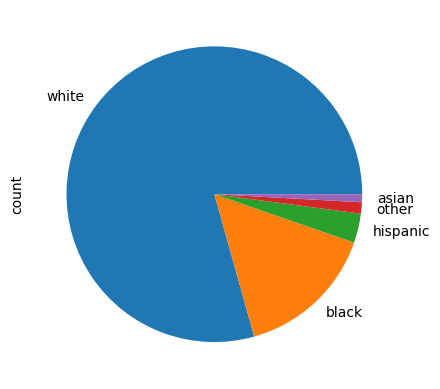

In [18]:
df["race"].value_counts().plot.pie()

In [1]:
# # Create the pipeline with balanced sampling
# tabpfn_pipe_2m = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ("select-k-best", SelectKBest(k=10)),
#     ('TabPFN_classifier', TabPFNClassifier(device="cpu", ignore_pretraining_limits=True))
# ])

# # Define scoring metrics
# scoring = {
#     'accuracy': 'accuracy',
#     'f1': 'f1_weighted',
#     'precision': 'precision_weighted',
#     'recall': 'recall_weighted'
# }

# # Cross validation
# strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Perform cross-validation
# cv_results = cross_validate(
#     tabpfn_pipe_2m,
#     X_train,
#     y_train,
#     cv=strat_kfold,
#     scoring=scoring,
#     n_jobs=1,
#     return_train_score=True
# )

# # Print results
# print("TabPFN Results:")
# print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std() * 2:.4f})")
# print(f"F1 Score: {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")
# print(f"Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std() * 2:.4f})")
# print(f"Recall: {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std() * 2:.4f})")

# # Fit the pipeline on the full training data
# tabpfn_pipe_2m.fit(X_train, y_train)

# # Get predictions on test data
# y_pred = tabpfn_pipe_2m.predict(X_test)

# # Create confusion matrix
# cm_tabpfn = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_tabpfn, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix - TabPFN')
# plt.ylabel('True Label')
# plt.xlabel('Predicted Label')
# plt.show()

# # Classification report
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

In [19]:
df.head(5)

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,surv2m,hday,diabetes,dementia,ca,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,0.262939,1,0,0,metastatic,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,0.001000,3,0,0,no,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,0.790894,4,0,0,no,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,0.698975,1,0,0,metastatic,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,0.634888,3,0,0,no,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [ ]:
# this is to inspect that what kind of data we have in our dataset
# plt.ion()
df.dtypes.value_counts(), df.dtypes.value_counts().plot.pie()
# plt.plot()
# plt.ioff()

### Univariate analysis

#### Class distribution

In [22]:
class_counts = df["surv6m"].value_counts()
print(class_counts)

surv2m
0.000000    139
0.823975     36
0.863892     35
0.822998     33
0.850952     33
           ... 
0.957886      1
0.164978      1
0.264954      1
0.076996      1
0.296997      1
Name: count, Length: 949, dtype: int64


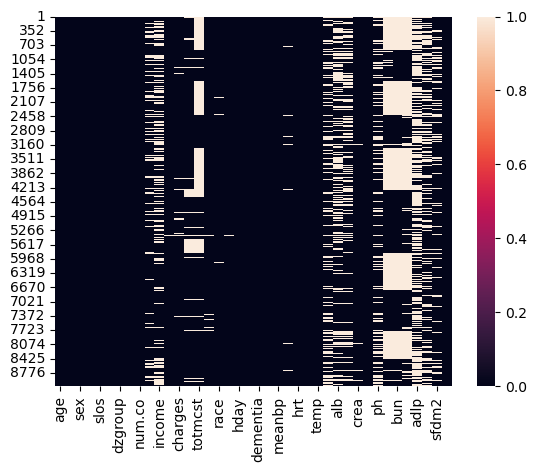

In [23]:
plt.ion()
sns.heatmap(df.isna())
plt.show()
# plt.close()
plt.ioff()

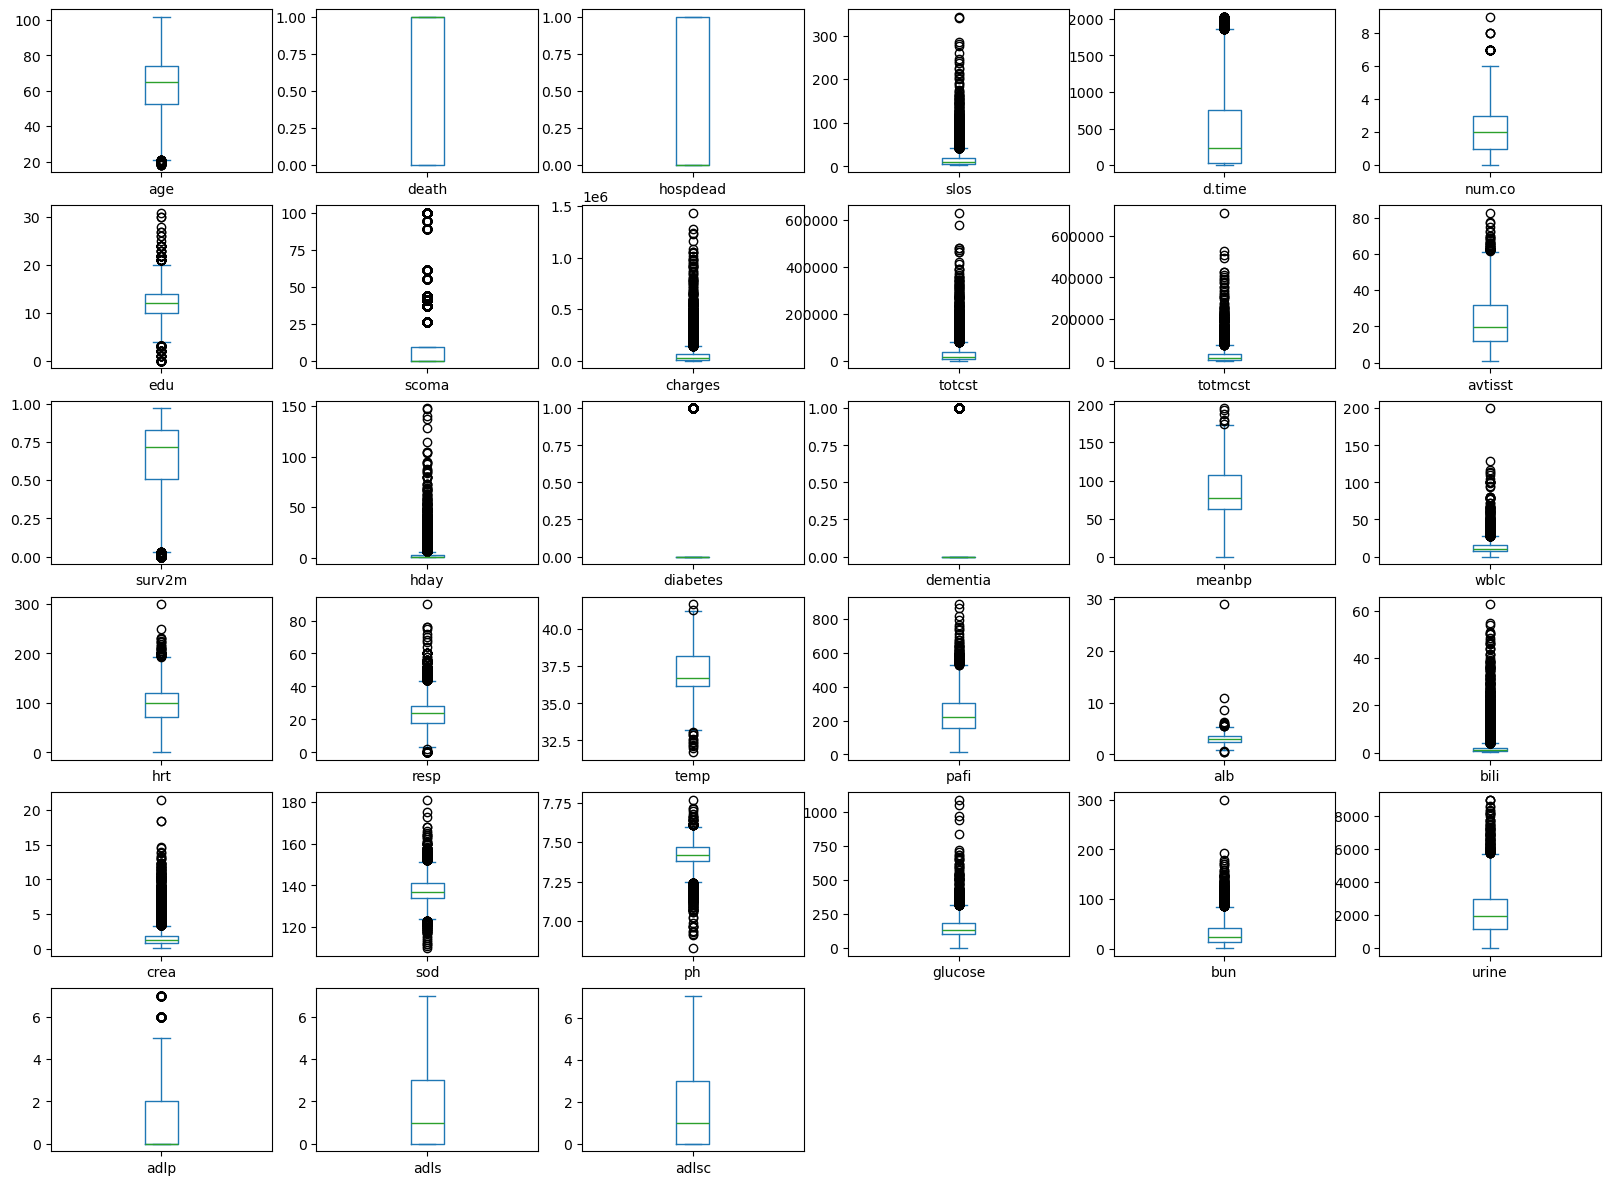

In [24]:
df.plot(kind = "box",layout = (10,6),figsize = (20,25), subplots = True)
plt.show()

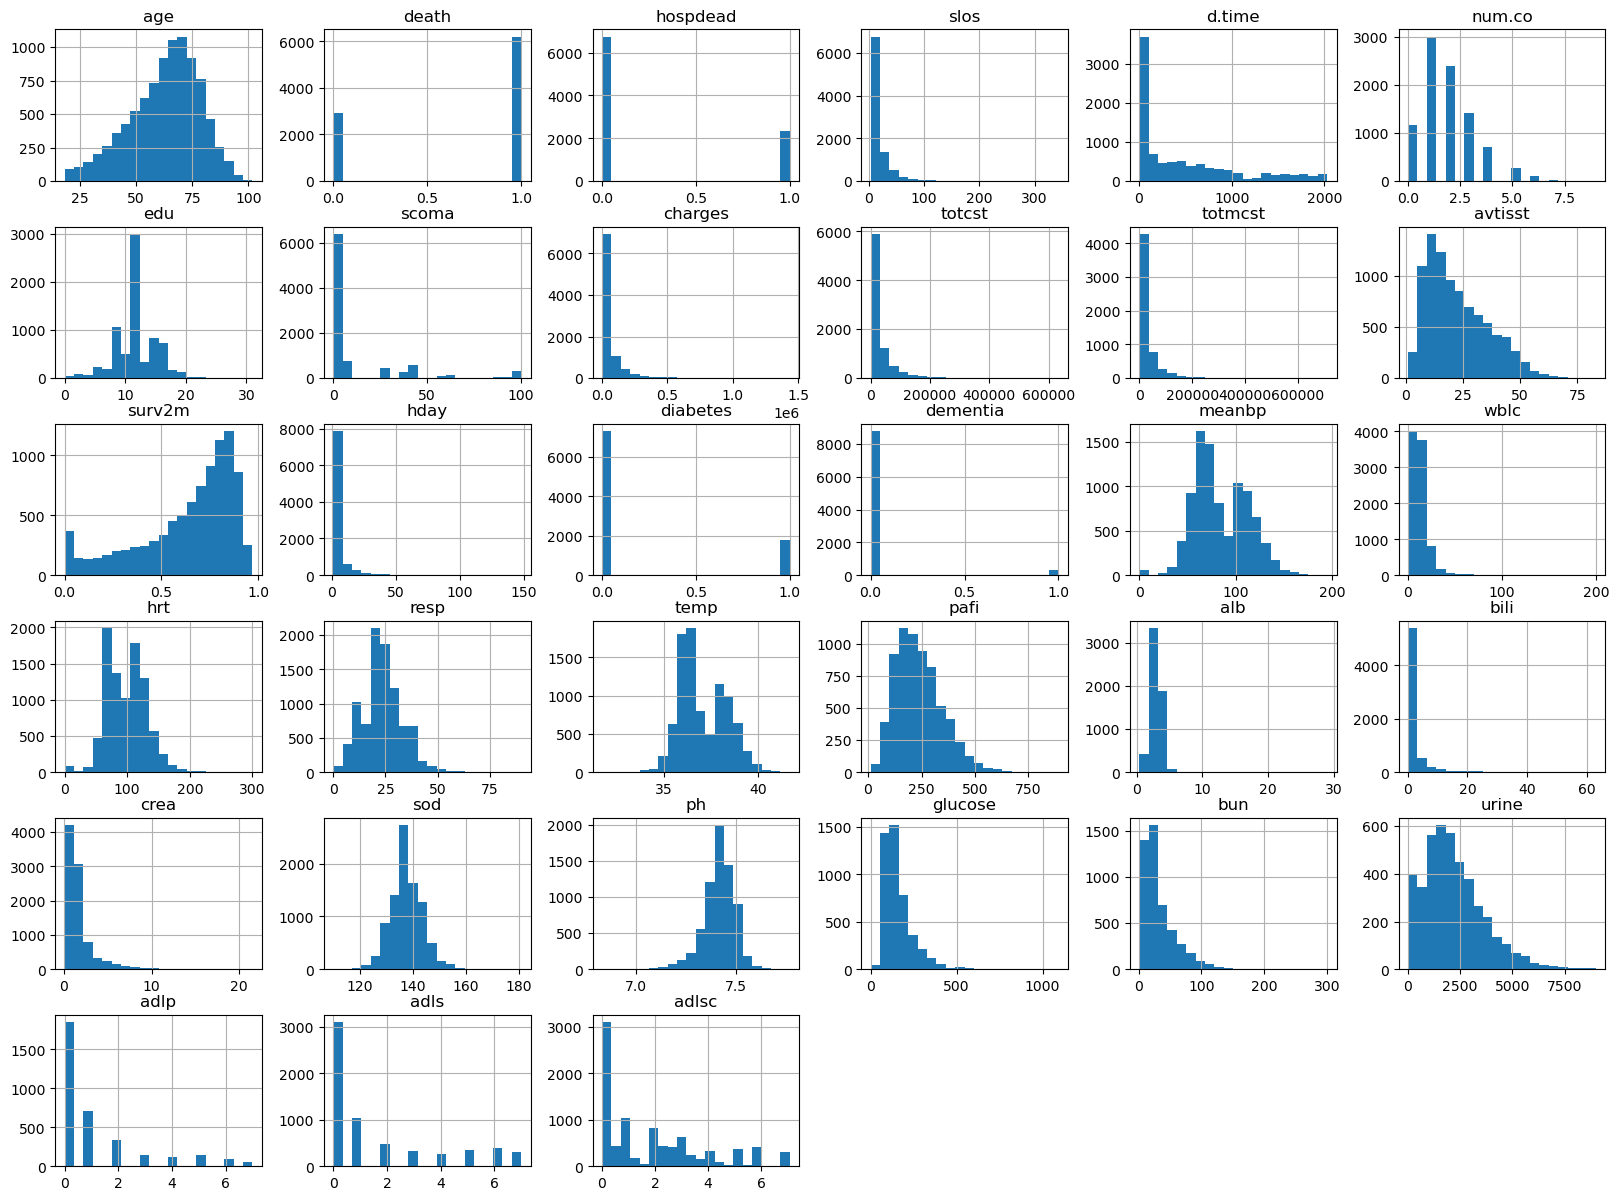

In [25]:
df.hist(layout = (10,6),figsize = (20,25), bins =20)
plt.show()

In [26]:
df.dtypes.value_counts()

float64    25
int64       8
object      7
Name: count, dtype: int64

In [14]:
numerical_vars_df = df.select_dtypes(include=[ 'float64'])
categorical_vars_df = df.select_dtypes(include=['int64', "object"])
obj_vars_df = df.select_dtypes(include=['object'])
#categorical_vars = pd.concat([int_vars, obj_vars])

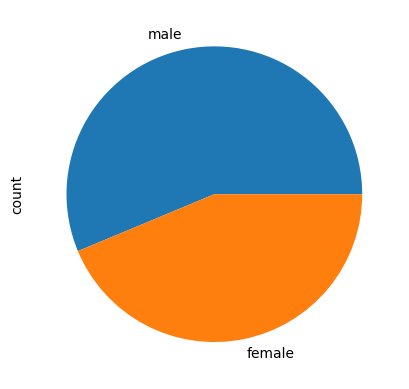

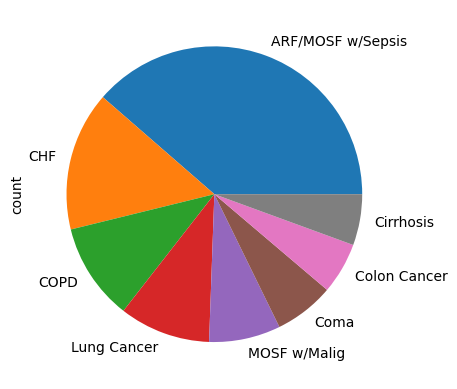

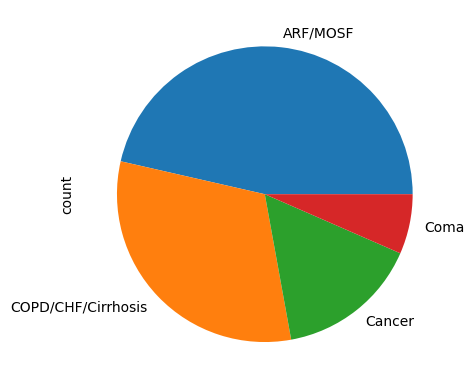

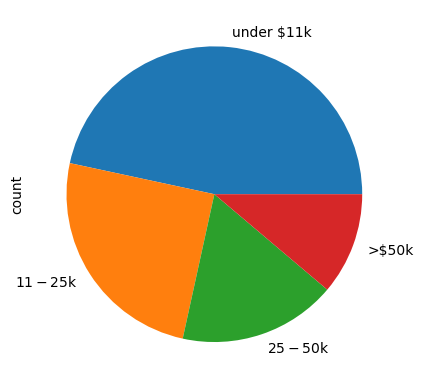

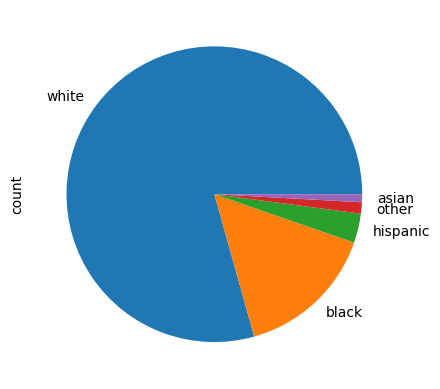

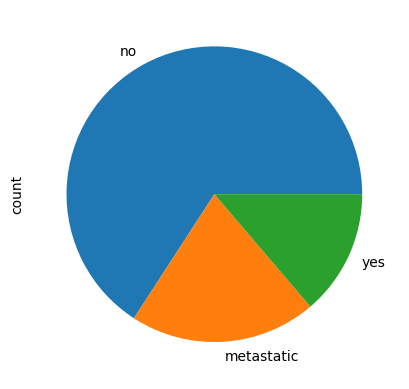

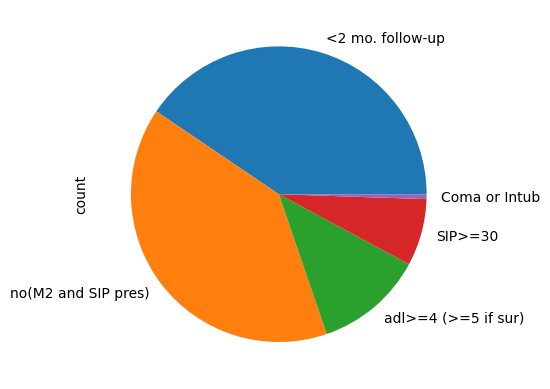

In [15]:
for i in obj_vars_df:

        obj_vars_df[i].value_counts().plot.pie()
        plt.show()

In [16]:
df.dtypes.value_counts(), numerical_vars_df.dtypes.value_counts(),categorical_vars_df.dtypes.value_counts()

(float64    25
 int64       8
 object      7
 Name: count, dtype: int64,
 float64    25
 Name: count, dtype: int64,
 int64     8
 object    7
 Name: count, dtype: int64)

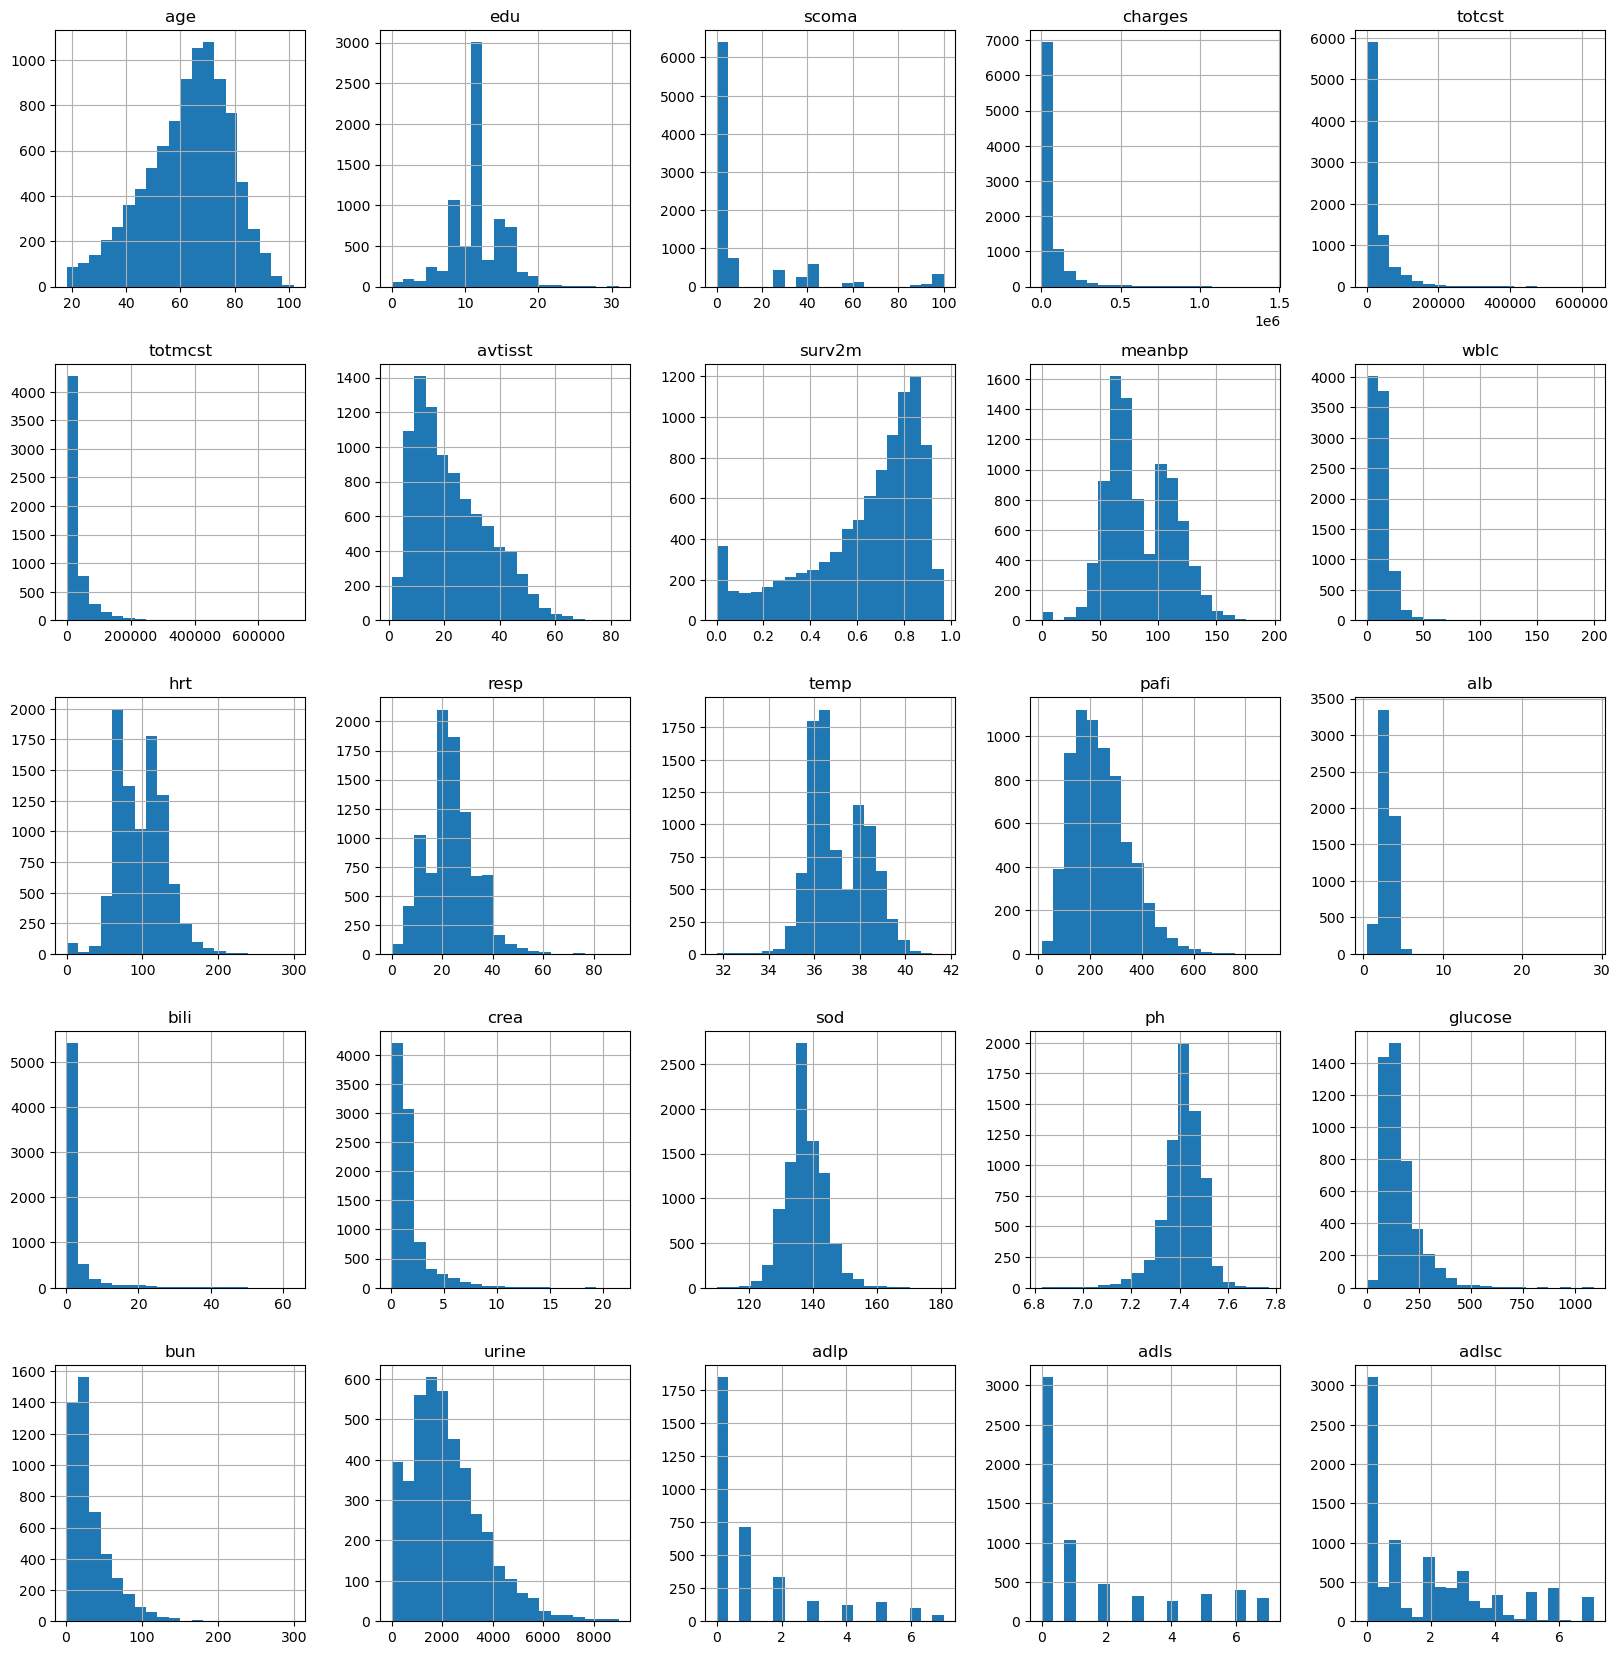

In [17]:
plt.ion()
numerical_vars_df.hist(layout= (6,5), figsize = (20,25), bins = 20)
plt.show()
plt.close()
plt.ioff()

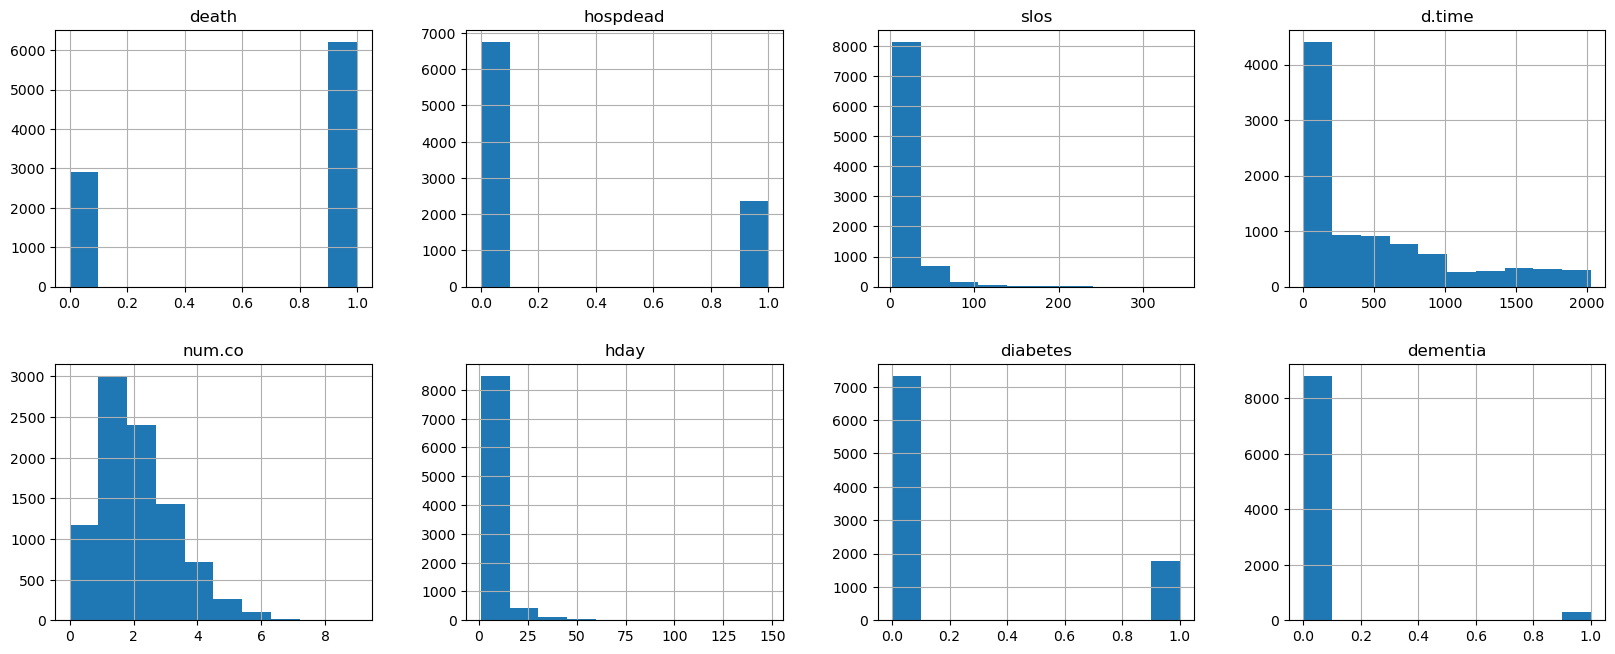

In [18]:
#in our categorical dataframe we have some data from object datatype and these can't be plotted with normal .hist function in pandas
plt.ion()
categorical_vars_df.hist(layout= (6,4), figsize = (20,25))
plt.show()
plt.close()
plt.ioff()

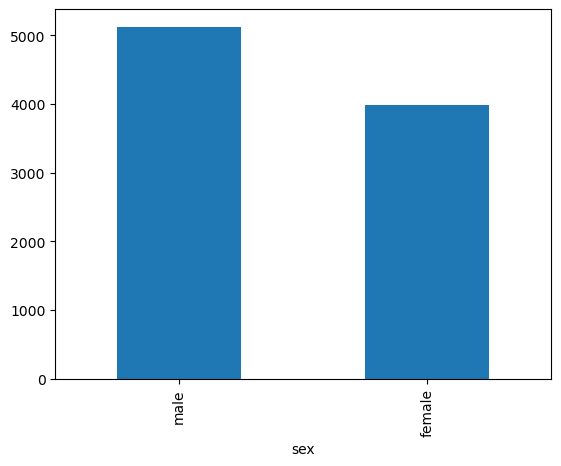

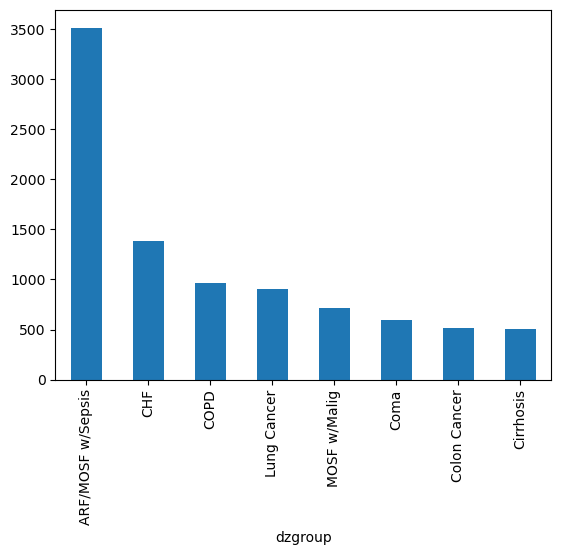

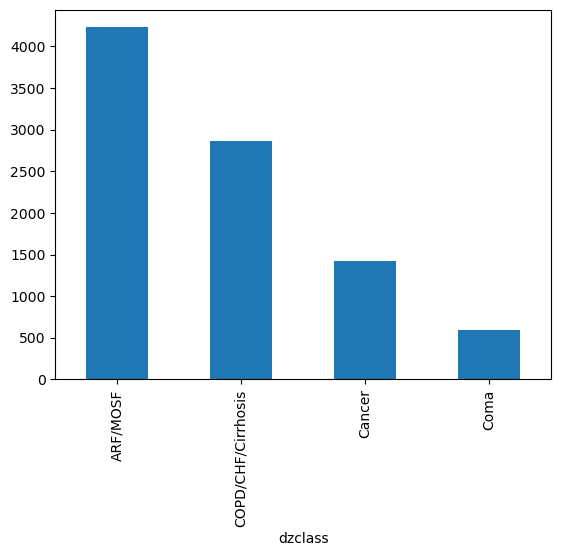

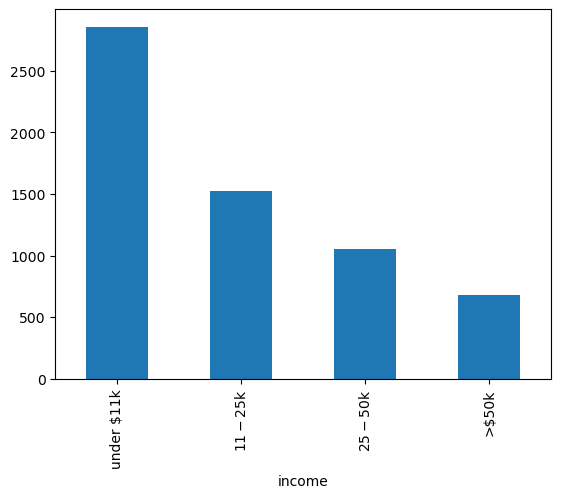

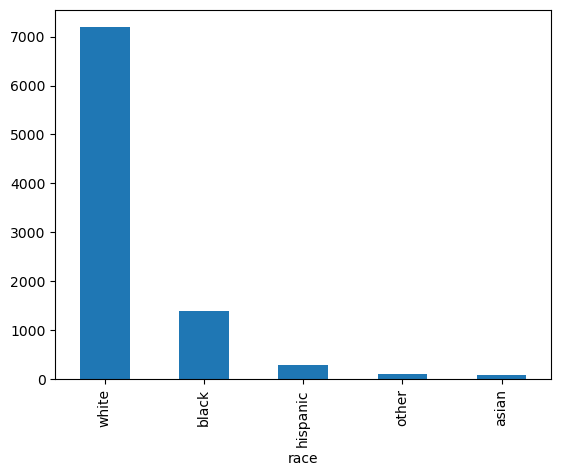

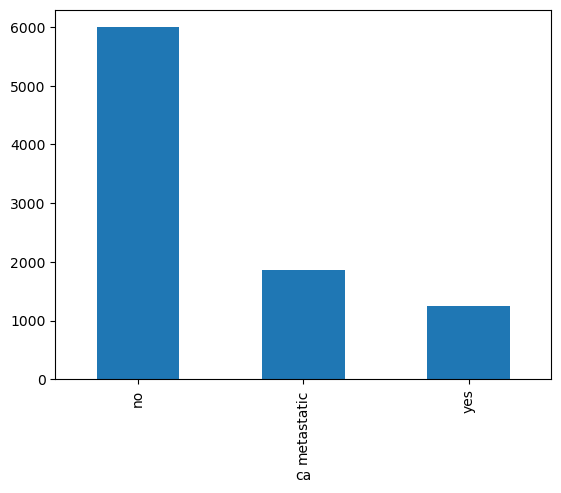

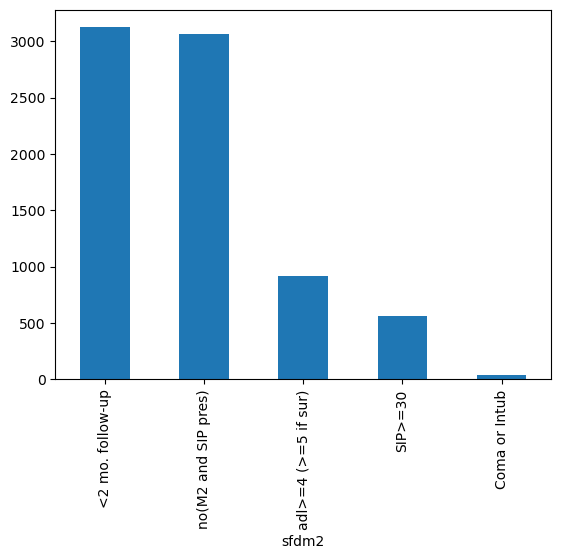

In [19]:
for i in obj_vars_df:
    categorical_vars_df[i].value_counts().plot(kind = "bar")
    plt.show()

In [ ]:
# scatter_matrix(numerical_vars, figsize = (20,25), alpha = 1, diagonal = "hist", c=df["surv2m"])

# plt.show()

In [20]:
for i in categorical_vars_df:
    print(df[i].value_counts(dropna = False))

death
1    6201
0    2904
Name: count, dtype: int64
sex
male      5125
female    3980
Name: count, dtype: int64
hospdead
0    6745
1    2360
Name: count, dtype: int64
slos
5      688
4      656
7      643
6      632
9      500
      ... 
140      1
104      1
339      1
223      1
189      1
Name: count, Length: 167, dtype: int64
d.time
4      238
5      194
7      180
6      155
8      144
      ... 
600      1
682      1
768      1
771      1
184      1
Name: count, Length: 1724, dtype: int64
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64
dzclass
ARF/MOSF              4227
COPD/CHF/Cirrhosis    2862
Cancer                1420
Coma                   596
Name: count, dtype: int64
num.co
1    3006
2    2397
3    1425
0    1177
4     714
5     263
6      98
7      21
8       3
9       1
Name: cou

In [ ]:
# import seaborn as sns

# # Example: Pair plot of selected columns
# sns.pairplot(df[['age', 'surv2m', 'sex', 'race']])
# plt.suptitle('Pair Plots of Selected Columns')
# plt.show()


In [ ]:
# numerical_vars

In [ ]:
# from pandas.plotting import scatter_matrix
# scatter_matrix(numerical_vars,
#                figsize = (50,50),
#                alpha = 1,
#                diagonal = 'hist')
# plt.show()

In [ ]:
# from pandas_profiling import ProfileReport
# prof = ProfileReport(numerical_vars)
# prof.to_file(output_file='output.html')



# #import sweetviz as sv
# import pandas as pd

# # Example DataFrame




In [ ]:
# # Pair plot using seaborn
# sns.pairplot(numerical_vars)
# plt.suptitle('Pair Plots of All Columns')
# plt.show()


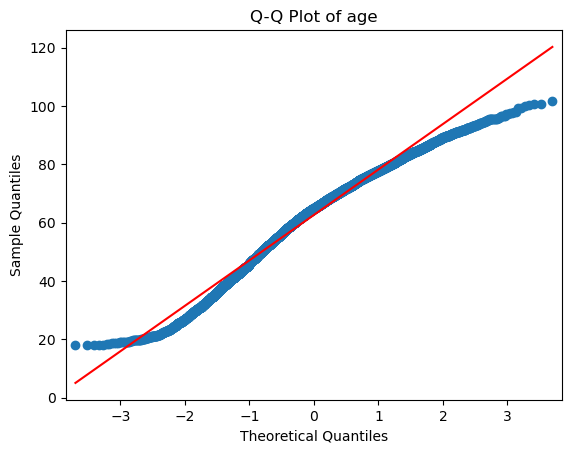

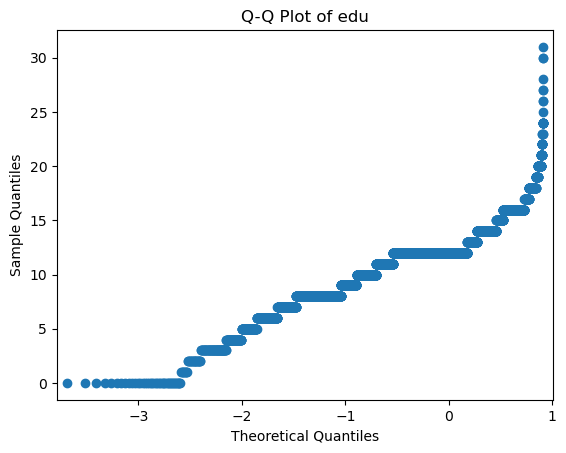

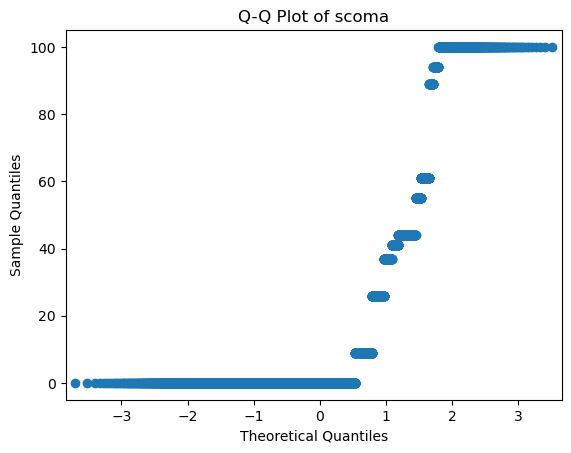

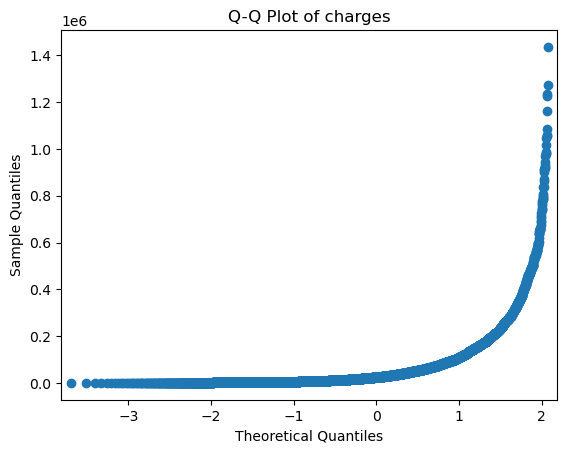

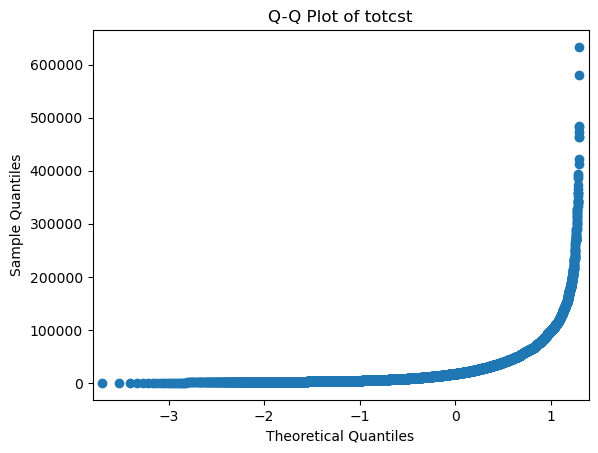

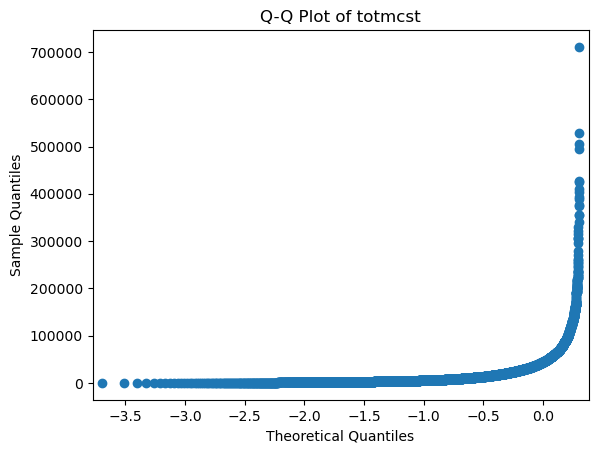

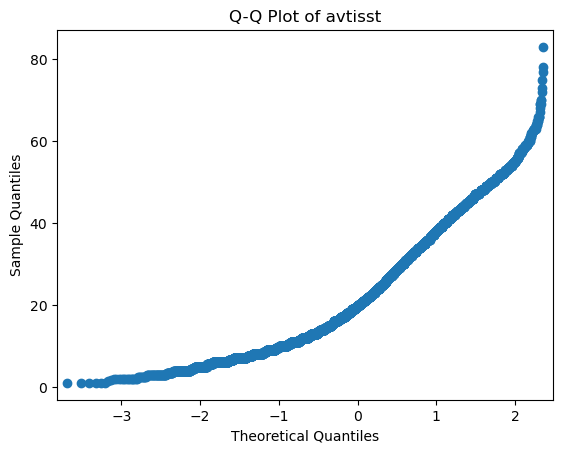

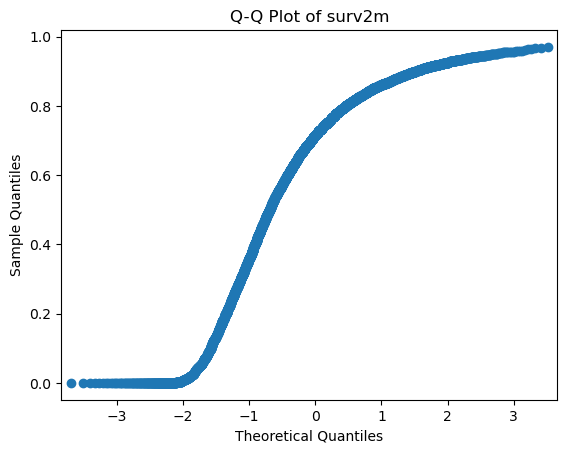

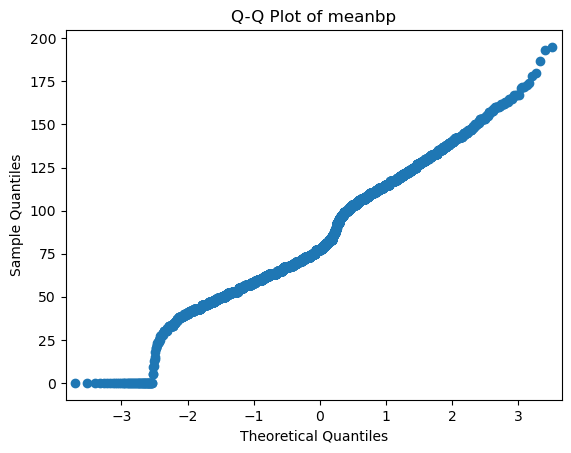

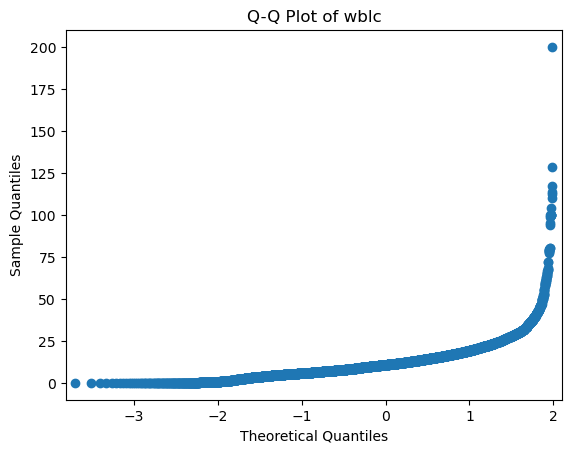

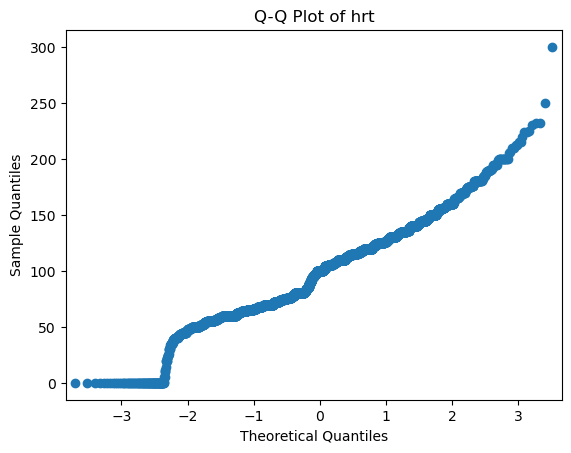

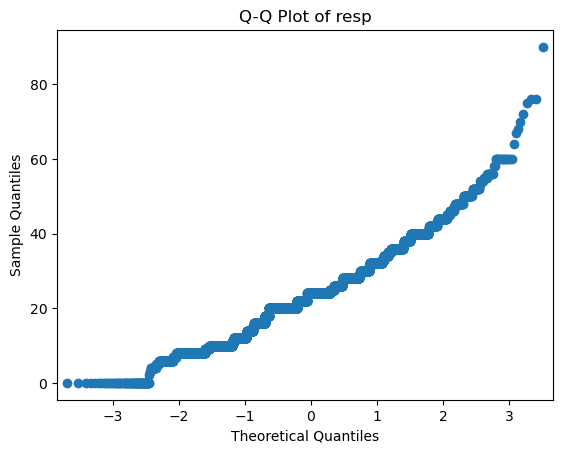

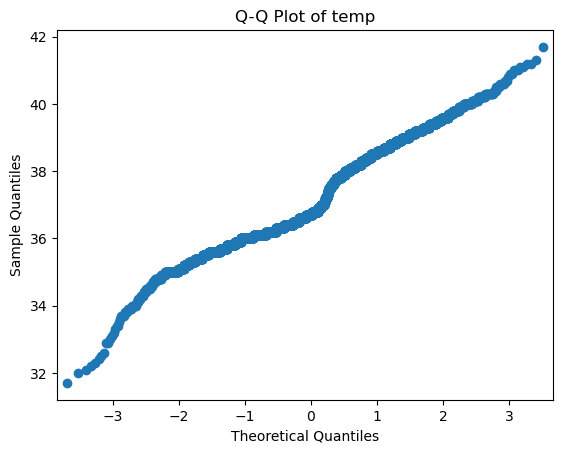

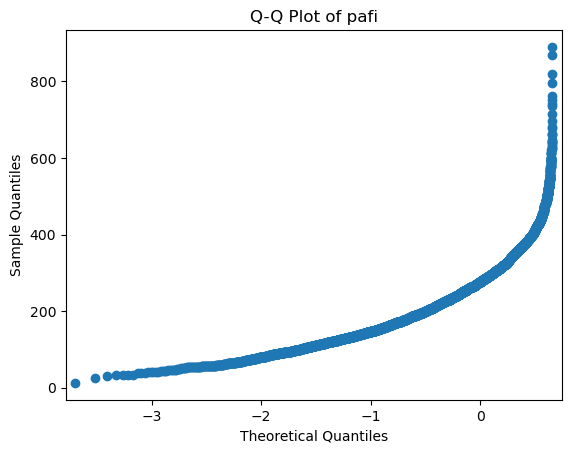

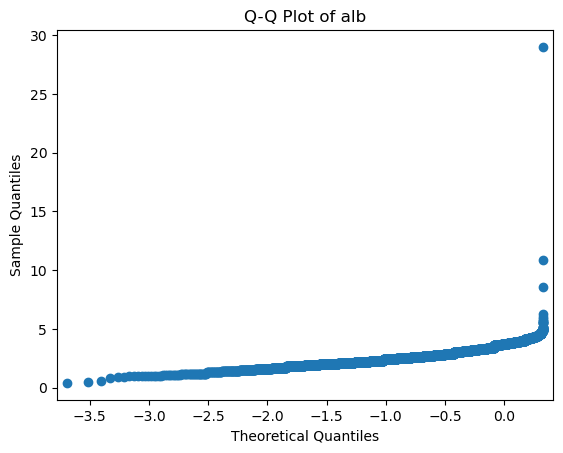

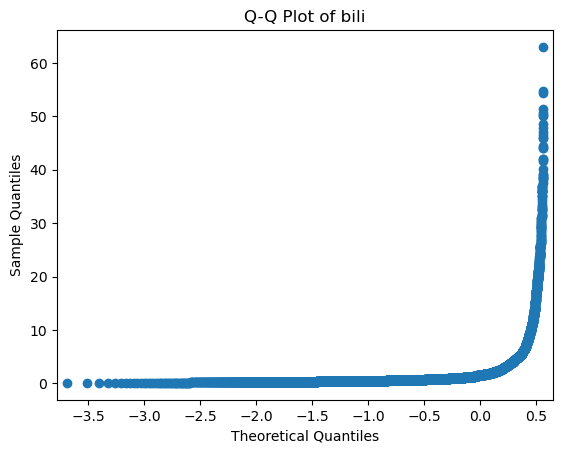

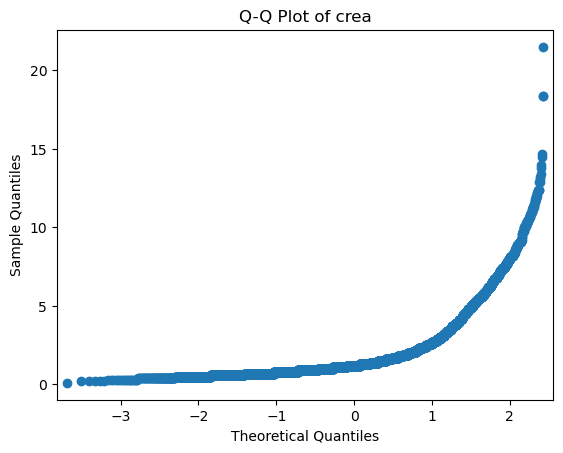

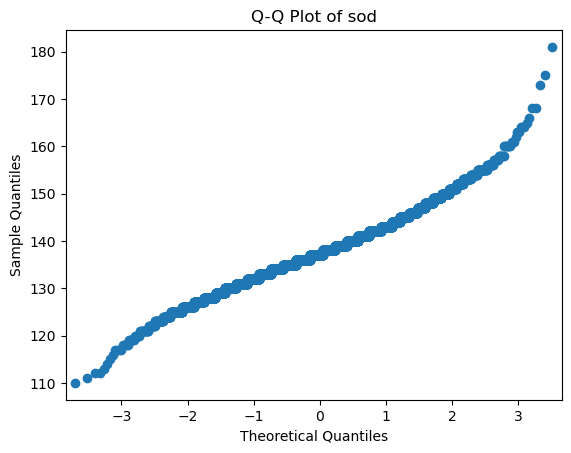

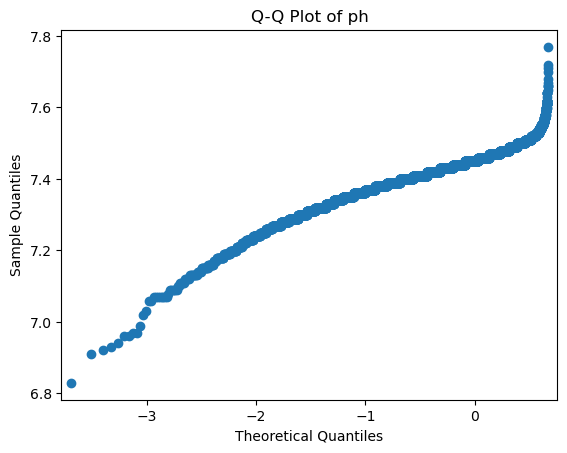

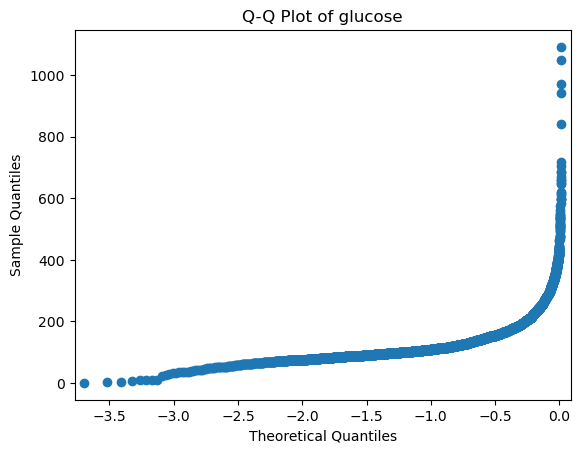

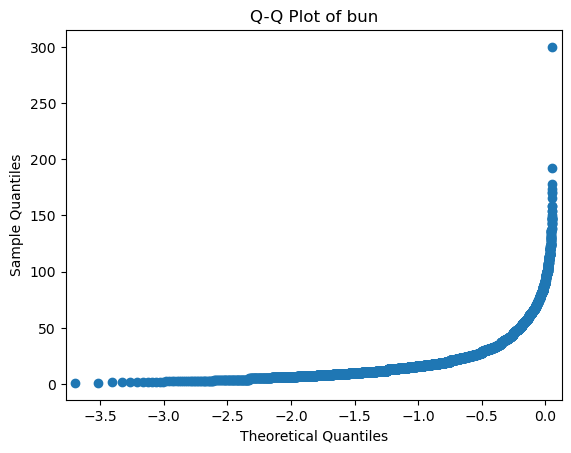

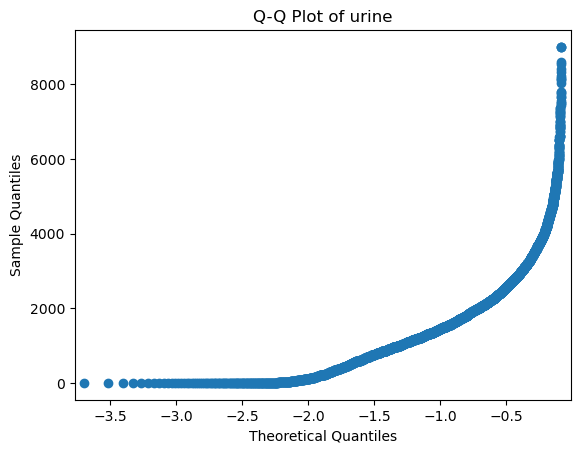

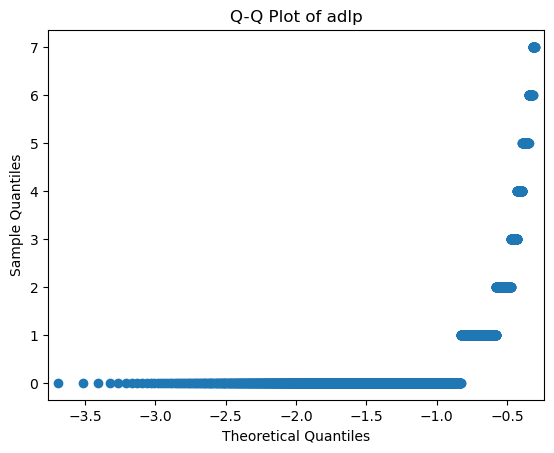

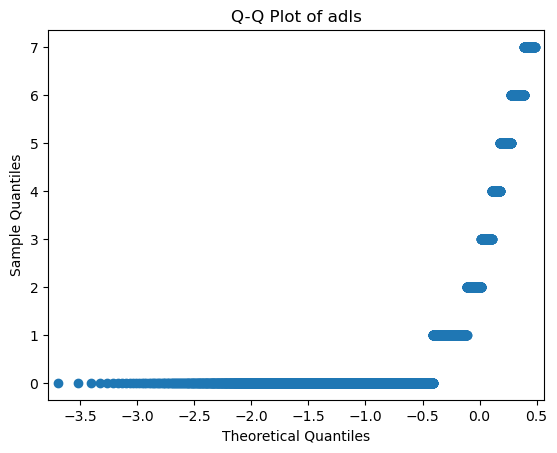

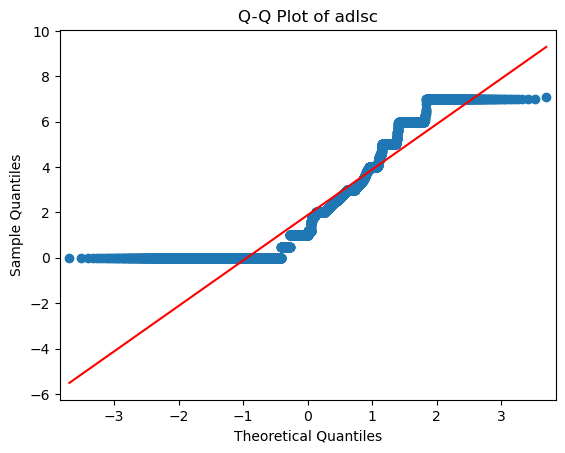

In [22]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.ion()  # Enable interactive mode

# Assuming numerical_vars is already defined
for i in numerical_vars:
    sm.qqplot(numerical_vars_df[i], line='s')
    plt.title(f'Q-Q Plot of {i}')
    plt.show()
    plt.close()  # Close the plot to free memory
plt.ioff()  # Disable interactive mode after plotting


<Figure size 2000x2000 with 0 Axes>

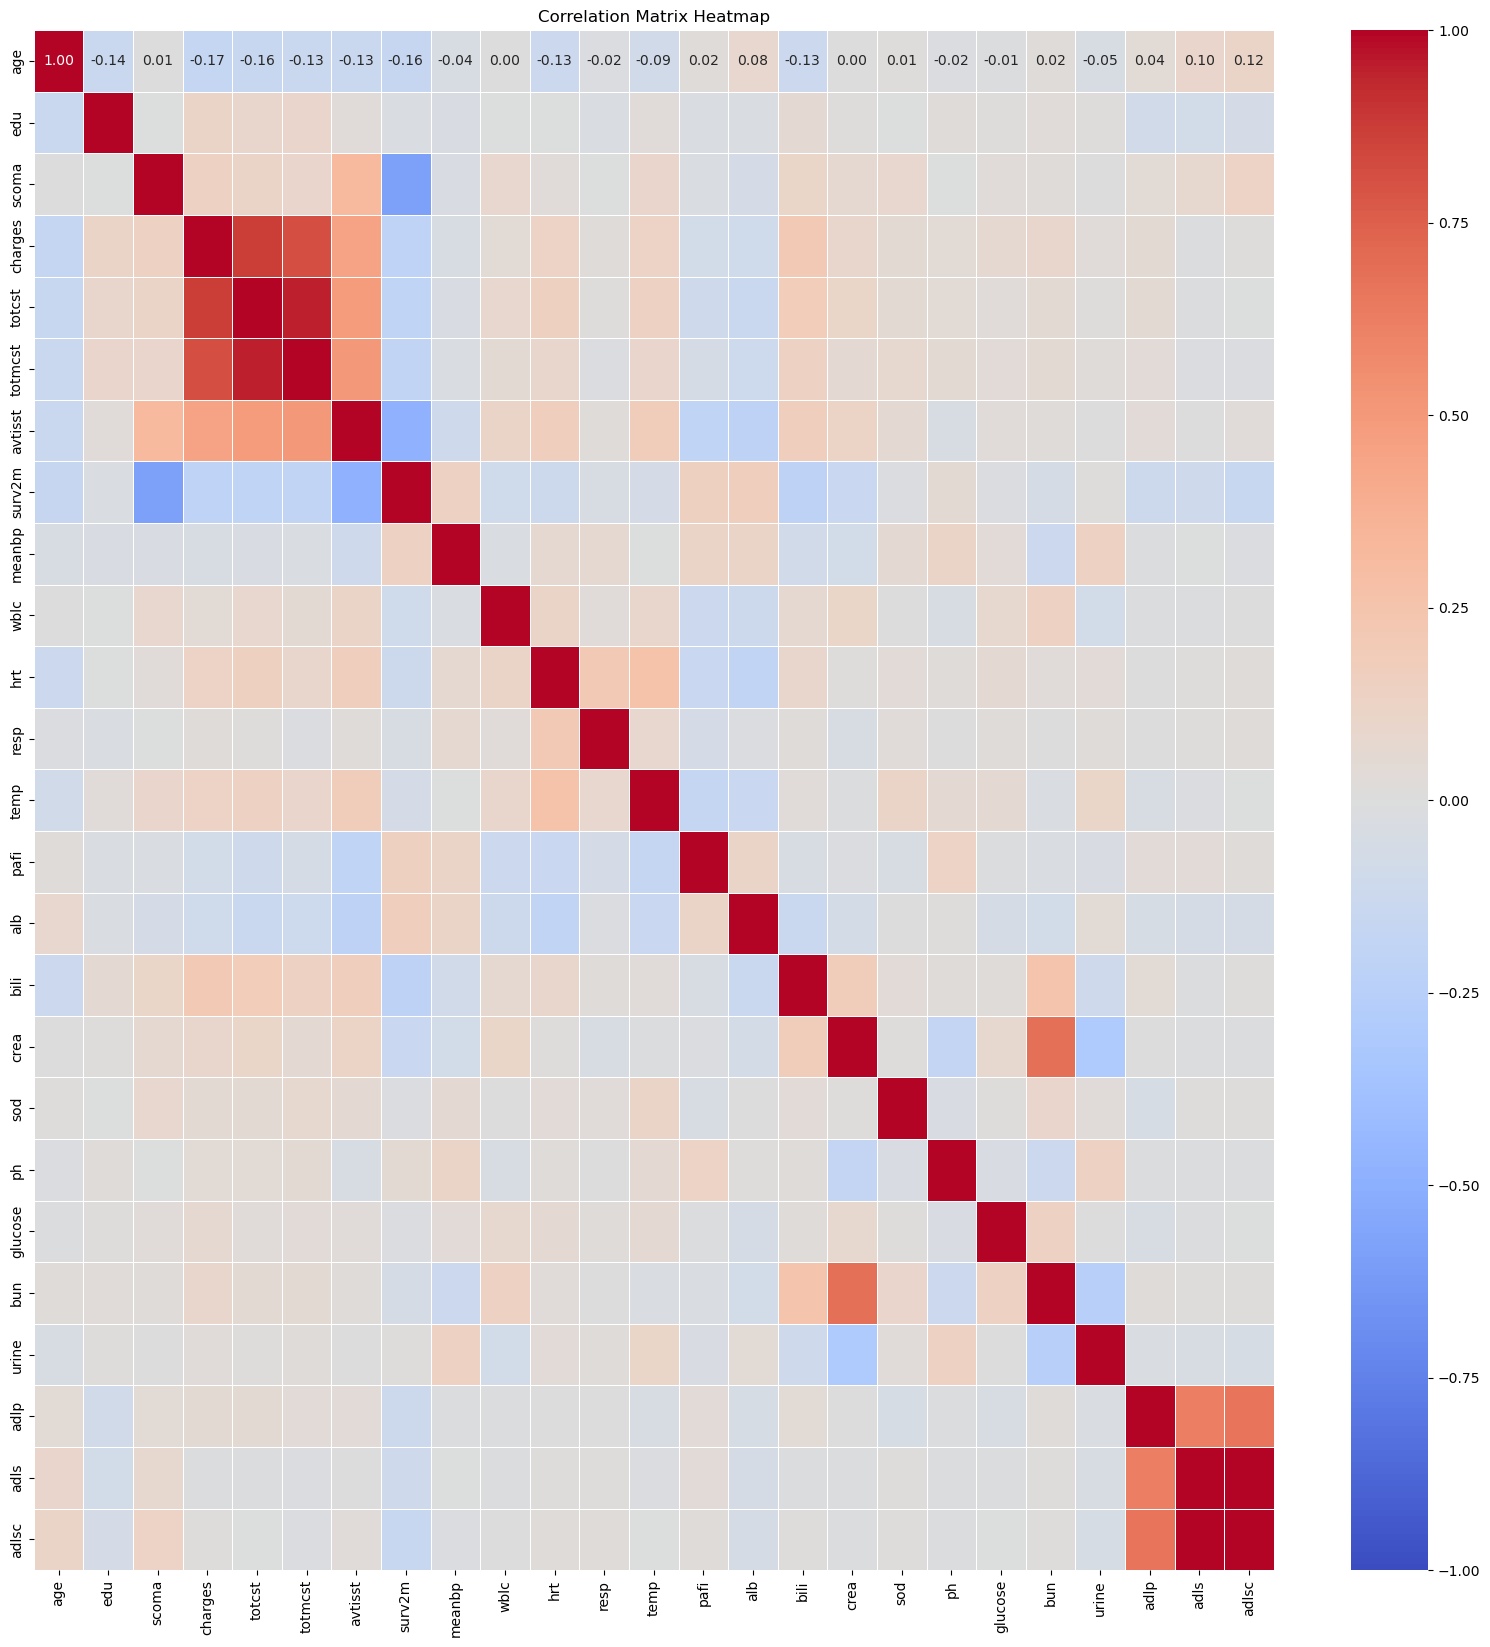

In [37]:
#correlation between numerical vars
# Plot heatmap of the correlation matrix
plt.figure(figsize=(20, 20))
sns.heatmap(numerical_vars_df.corr(), annot=True, linewidths= .5, fmt = ".2f", vmin = -1, vmax = 1, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


In [38]:
df.columns

Index(['age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'surv2m', 'hday', 'diabetes', 'dementia',
       'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili',
       'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')

In [ ]:
for col in categorical_vars_df :
    plt.ion()
    sns.heatmap(pd.crosstab(df['surv2m'], df[col]), annot=True, fmt='d')
    plt.figure()
    plt.close()  # Close the plot to free memory
    plt.ioff()

In [ ]:
df.surv2m

### rough preprocessing and building a model

In [7]:
df.surv2m

1       0.262939
2       0.001000
3       0.790894
4       0.698975
5       0.634888
          ...   
9101    0.852905
9102    0.553955
9103    0.741943
9104    0.177979
9105    0.832886
Name: surv2m, Length: 9105, dtype: float64

In [8]:
df.head()

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,surv2m,hday,diabetes,dementia,ca,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,NaN,7.000000,other,0.262939,1,0,0,metastatic,97.0,6.000000,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,NaN,29.000000,white,0.001000,3,0,0,no,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,NaN,13.000000,white,0.790894,4,0,0,no,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,NaN,7.000000,white,0.698975,1,0,0,metastatic,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,NaN,18.666656,white,0.634888,3,0,0,no,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [9]:
df.shape

(9105, 40)

In [10]:
df.isna().sum()

age            0
death          0
sex            0
hospdead       0
slos           0
d.time         0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
surv2m         1
hday           0
diabetes       0
dementia       0
ca             0
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
sfdm2       1400
adlsc          0
dtype: int64

In [10]:
for i in df:
    print(f"missing values for {i}: {(df[i].isna().sum()/len(df))*100}")
    

missing values for age: 0.0
missing values for death: 0.0
missing values for sex: 0.0
missing values for hospdead: 0.0
missing values for slos: 0.0
missing values for d.time: 0.0
missing values for dzgroup: 0.0
missing values for dzclass: 0.0
missing values for num.co: 0.0
missing values for edu: 17.946183415705654
missing values for income: 32.75123558484349
missing values for scoma: 0.010982976386600769
missing values for charges: 1.8890719384953323
missing values for totcst: 9.752883031301483
missing values for totmcst: 38.165842943437674
missing values for avtisst: 0.900604063701263
missing values for race: 0.46128500823723234
missing values for surv6m: 0.010982976386600769
missing values for hday: 0.0
missing values for diabetes: 0.0
missing values for dementia: 0.0
missing values for ca: 0.0
missing values for meanbp: 0.010982976386600769
missing values for wblc: 2.328390993959363
missing values for hrt: 0.010982976386600769
missing values for resp: 0.010982976386600769
missing v

## Data Preprocessing

### Handling missing values

In [7]:
# these columns have less than 2% missing values so we can get rid of the missing values from these columns
# other columns have more missing values therefore we would try to impute those columns
columns_to_check = ["scoma", "charges", "avtisst", "race", 
                    "meanbp", "wblc", "hrt", "resp", "temp", "crea", "sod"]

# Drop rows where any of the specified columns have missing values
df_afterdropping = df.dropna(subset=columns_to_check)

In [8]:
df_afterdropping.columns

Index(['age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'surv6m', 'hday', 'diabetes', 'dementia',
       'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili',
       'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')

In [10]:
# train test split
df_afterdropping['surv6m']=pd.cut(df.surv6m,bins = 4, labels = [0,1,2,3])
X = df_afterdropping.drop(["surv6m"], axis = 1)
y = df_afterdropping["surv6m"]
mode_value = y.mode()[0]
y = y.fillna(mode_value)
# y.iloc[5393] = mode_value
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 42)

C:\Users\fardi\AppData\Local\Temp\ipykernel_19464\3270169359.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afterdropping['surv6m']=pd.cut(df.surv6m,bins = 4, labels = [0,1,2,3])


In [11]:
len(X_train), len(y_train)

(6866, 6866)

In [12]:
for i in X_train:
    print(f"missing values for {i}: {(X_train[i].isna().sum()/len(df))*100}")
   

missing values for age: 0.0
missing values for death: 0.0
missing values for sex: 0.0
missing values for hospdead: 0.0
missing values for slos: 0.0
missing values for d.time: 0.0
missing values for dzgroup: 0.0
missing values for dzclass: 0.0
missing values for num.co: 0.0
missing values for edu: 13.223503569467326
missing values for income: 24.12959912136189
missing values for scoma: 0.0
missing values for charges: 0.0
missing values for totcst: 6.622734761120263
missing values for totmcst: 28.940142778693023
missing values for avtisst: 0.0
missing values for race: 0.0
missing values for hday: 0.0
missing values for diabetes: 0.0
missing values for dementia: 0.0
missing values for ca: 0.0
missing values for meanbp: 0.0
missing values for wblc: 0.0
missing values for hrt: 0.0
missing values for resp: 0.0
missing values for temp: 0.0
missing values for pafi: 18.198791872597475
missing values for alb: 27.182866556836906
missing values for bili: 20.889621087314662
missing values for crea:

In [13]:
categorical_df_obj = X_train.select_dtypes(include = ["object"])
categorical_df_int = X_train.select_dtypes(include = ["int64"])
categorical_df = pd.concat([categorical_df_obj, categorical_df_int])
numerical_df = X_train.select_dtypes(include = ['float64'])


In [14]:
categorical_df.drop(["income", "sfdm2"], axis = 1).columns

Index(['sex', 'dzgroup', 'dzclass', 'race', 'ca', 'death', 'hospdead', 'slos',
       'd.time', 'num.co', 'hday', 'diabetes', 'dementia'],
      dtype='object')

In [57]:
y_train.isna().sum()

0

### Imputation of the data

## making a pipeline with SVC
#### this one works too

In [15]:
# to see if we have data imbalance or not
y_train.value_counts(), len(y_train)

(surv6m
 2    2401
 3    1895
 1    1352
 0    1218
 Name: count, dtype: int64,
 6866)

In [16]:
# Identify categorical and numerical columns
# numerical_vars_df = df.select_dtypes(include=[ 'float64'])
# categorical_vars_df = df.select_dtypes(include=['int64', "object"])
# obj_vars_df = df.select_dtypes(include=['object'])

numerical_df = df.select_dtypes(["float64"])
numerical_cols = list(numerical_df.columns)
additional_cols = ['death', 'hospdead', 'slos', 'd.time', 'num.co', 'hday', 'diabetes', 'dementia']
numerical_cols.extend(additional_cols)
numerical_cols = list(set(numerical_cols))
numerical_cols.remove("surv6m")

ordinal_cols = ['income', 'sfdm2']

onehot_cols = categorical_df.drop(["income", "sfdm2",'death', 'hospdead', 'slos',
       'd.time', 'num.co', 'hday', 'diabetes', 'dementia'], axis = 1).columns
print(ordinal_cols)
print(numerical_cols)
print(onehot_cols)


['income', 'sfdm2']
['age', 'scoma', 'alb', 'totmcst', 'd.time', 'pafi', 'totcst', 'wblc', 'glucose', 'adls', 'adlsc', 'ph', 'avtisst', 'death', 'adlp', 'urine', 'hospdead', 'edu', 'slos', 'sod', 'dementia', 'diabetes', 'temp', 'bili', 'bun', 'hday', 'num.co', 'crea', 'meanbp', 'charges', 'hrt', 'resp']
Index(['sex', 'dzgroup', 'dzclass', 'race', 'ca'], dtype='object')


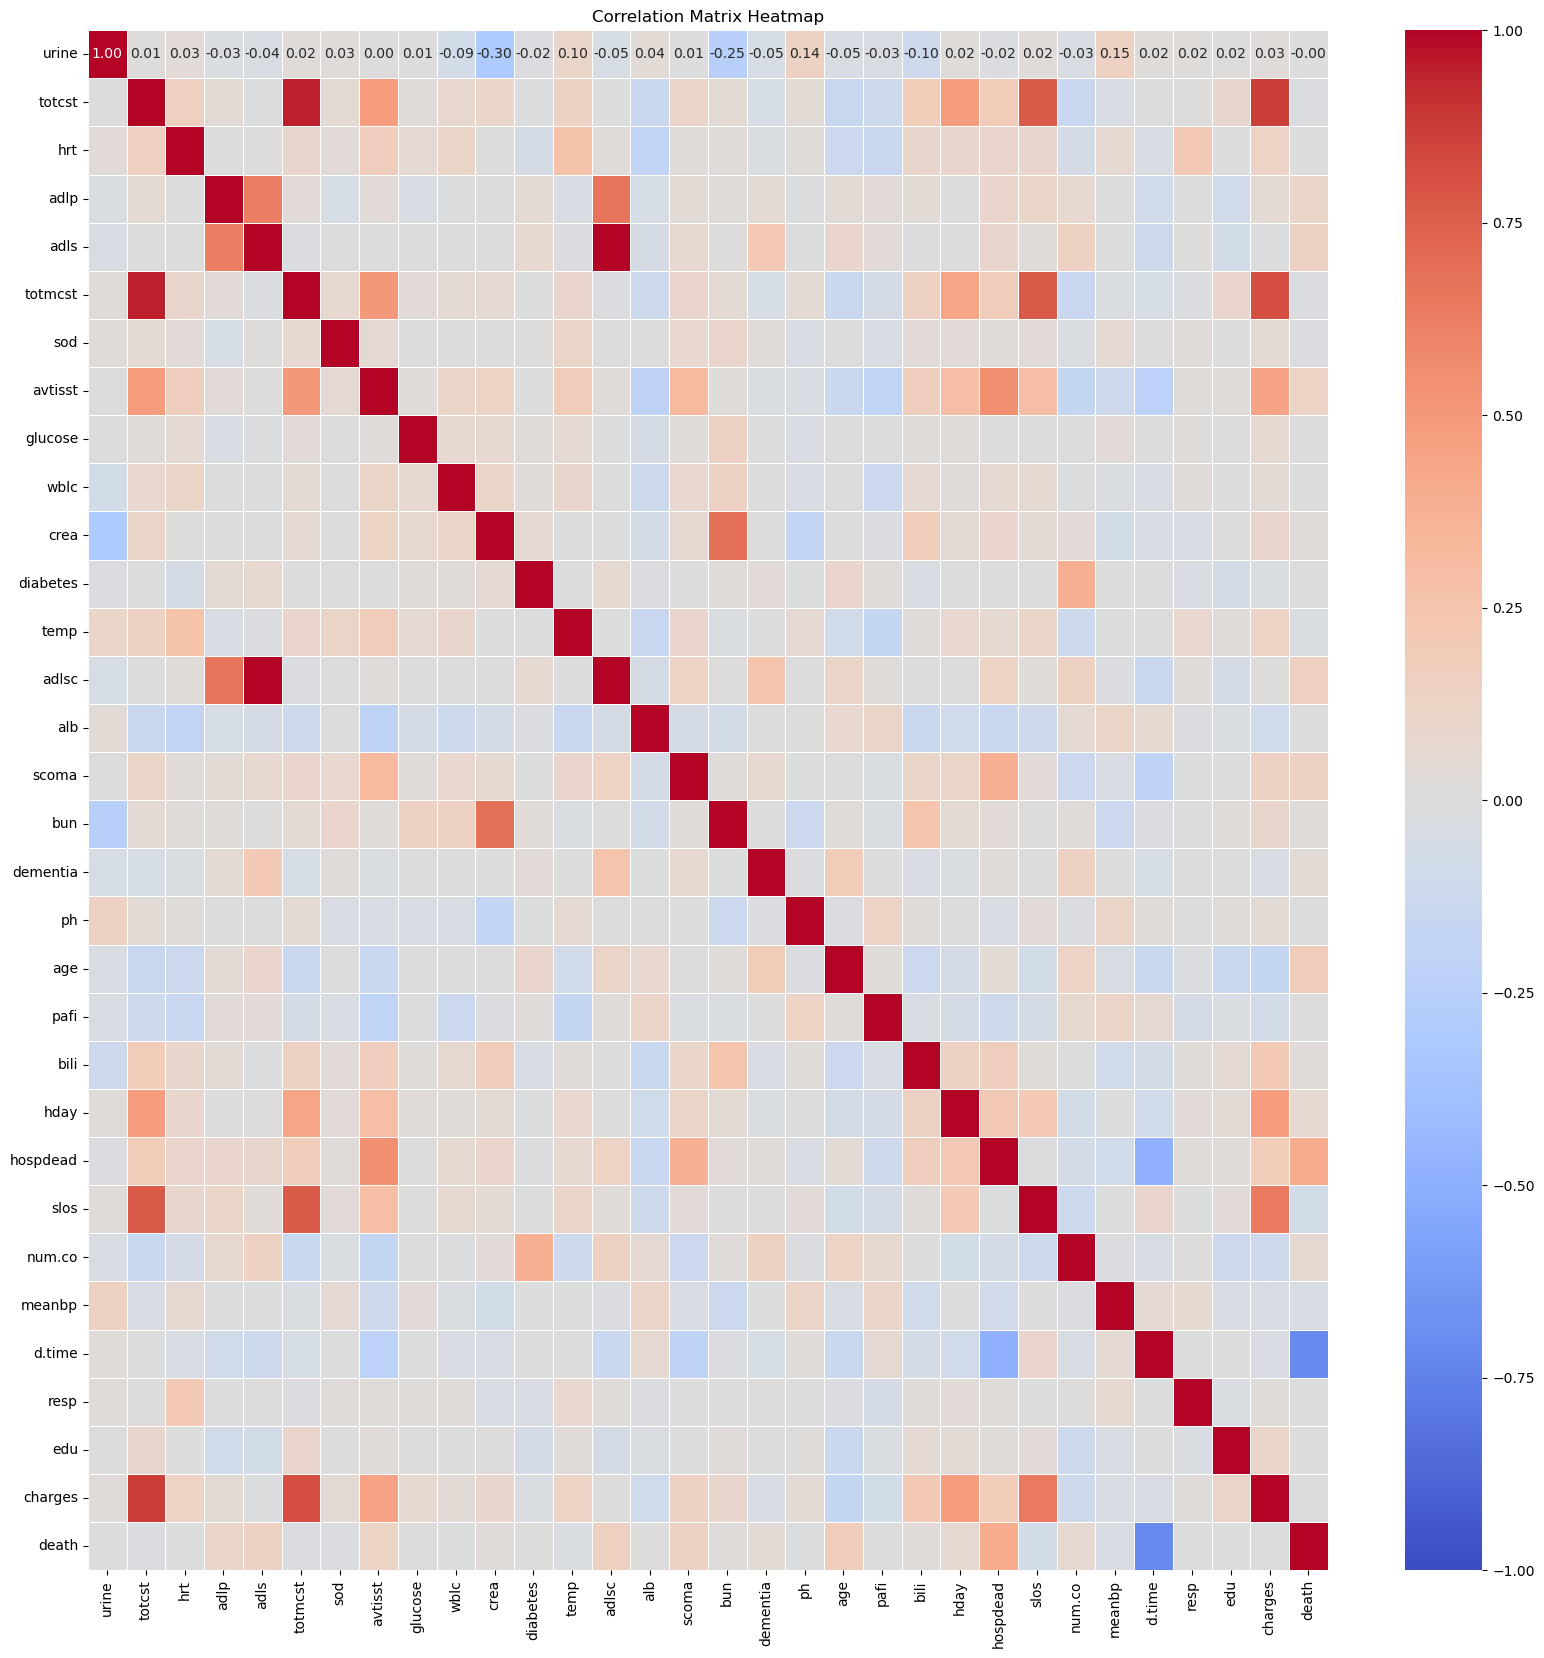

In [30]:
plt.figure(figsize=(20, 20))
sns.heatmap(df[numerical_cols].corr(), annot=True, linewidths= .5, fmt = ".2f", vmin = -1, vmax = 1, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [31]:
X_train.shape, y_train.shape

((6866, 39), (6866,))

#### Run this if you don't want to perform any preprocessing steps and straight want to go to developing the model

In [32]:
X_train.head()

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,hday,diabetes,dementia,ca,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
2930,91.71796,0,female,0,19,668,ARF/MOSF w/Sepsis,ARF/MOSF,4,6.0,under $11k,0.0,52128.0,38784.8750,30594.6875,26.333328,white,2,1,0,no,43.0,15.500000,113.0,16.0,37.79688,154.00000,1.899902,0.099991,0.899902,146.0,7.299805,186.0,14.0,1338.0,NaN,2.0,adl>=4 (>=5 if sur),2.000000
65,64.64294,1,male,0,17,254,ARF/MOSF w/Sepsis,ARF/MOSF,3,12.0,NaN,9.0,180786.0,95272.6875,NaN,25.333328,white,17,1,0,no,68.0,13.298828,92.0,38.0,38.79688,113.67188,3.399902,1.099854,2.299805,133.0,7.479492,NaN,NaN,NaN,NaN,0.0,no(M2 and SIP pres),0.000000
7075,65.69196,1,male,0,25,253,ARF/MOSF w/Sepsis,ARF/MOSF,2,18.0,NaN,0.0,54606.0,36313.7812,40016.8125,24.250000,white,4,0,0,yes,53.0,13.500000,114.0,12.0,35.39844,226.65625,1.799805,4.099609,2.500000,134.0,7.419922,194.0,30.0,362.0,NaN,0.0,no(M2 and SIP pres),0.000000
7040,67.25299,1,male,0,11,24,Lung Cancer,Cancer,2,NaN,NaN,0.0,12915.0,8760.2344,12108.2891,18.000000,white,1,0,0,metastatic,129.0,10.199219,146.0,38.0,36.79688,436.00000,NaN,NaN,1.299805,141.0,7.419922,119.0,27.0,820.0,NaN,NaN,<2 mo. follow-up,4.027344
6759,37.34998,0,male,0,68,1073,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,205034.0,133860.3750,153891.2500,49.750000,white,2,1,0,no,62.0,14.199219,120.0,34.0,38.29688,240.00000,NaN,NaN,2.299805,144.0,7.419922,308.0,83.0,4245.0,NaN,NaN,NaN,3.105957


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.svm import SVC
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest





def dummify(X):
    return pd.get_dummies(X)

# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Define the preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']])),
    ('scaler', RobustScaler())
])
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # ('dummify', FunctionTransformer(dummify)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output = False)),
    ('scaler', RobustScaler())
])



preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ordinal_cat', ordinal_transformer, ordinal_cols),
        ("onehot_cat", onehot_transformer, onehot_cols)
    ])

# SVC pipeline
svc_pipe_2m = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    # ('pca', PCA(n_components=0.95)),
    ("select-k-best", SelectKBest(k = 10)),
    ("SMOTE", SMOTE(random_state = 42)),
    # ('correlation_plotter', CorrelationMatrixPlotter(feature_names=numerical_cols + ordinal_cols + onehot_cols)),
    ('svm', SVC(class_weight= "balanced"))
])



# Fit the pipeline on the training data for 2-month survival
svc_pipe_2m.fit(X_train, y_train)


# cross validation
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_svm = cross_val_predict(svc_pipe_2m, X, y, cv=strat_kfold, n_jobs=-1)

# Cross validation
# strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(svc_pipe_2m, X_train, y_train, cv=strat_kfold, scoring='roc_auc')

# # Print the cross-validation scores
# print(f'Cross-Validation AUC Scores: {scores}')
# print(f'Mean AUC Score: {np.mean(scores)}')




C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [34]:
svc_pipe_2m

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['urine', 'totcst', 'hrt',
                                                   'adlp', 'adls', 'totmcst',
                                                   'sod', 'avtisst', 'glucose',
                                                   'wblc', 'crea', 'diabetes',
                                                   'temp', 'adlsc', 'alb',
                                                   'scoma', 'bun', 'dementia',
                                                   'ph', 'age', 'pafi', 'bili',
                                                   'hday', 'hospdead', 'slos',
                                                   'num.co', 'me...
                                                  ['income', 'sfdm2']),
                                                 ('onehot_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['sex', 'dzgroup', 'dzclass', 'race', 'ca'], dtype='object'))])),
                ('select-k-best', SelectKBest()),
                ('SMOTE', SMOTE(random_state=42)),
                ('svm', SVC(class_weight='balanced'))])

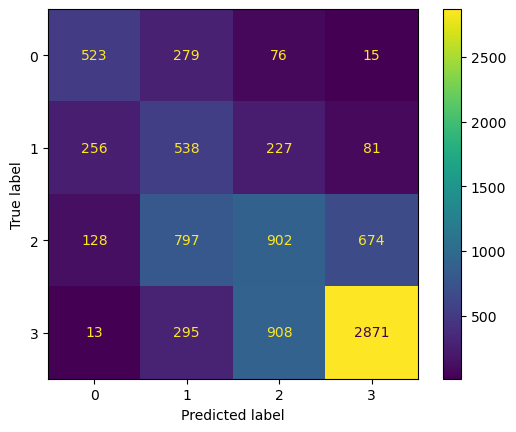

In [35]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y, y_pred_svm,values_format = '')
plt.show()

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

# RocCurveDisplay.from_estimator(svc_pipe_2m, X_test, y_test, plot_chance_level=True, marker = 'o')
# plt.title("Receiver Operating Characteristic (ROC) curves")
# plt.grid(linestyle="--")
# plt.show()

In [19]:
y_pred_svc_test = svc_pipe_2m.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_svc_test))
print('F1-score %s' % f1_score(y_test, y_pred_svc_test, average=None))
print(classification_report(y_test, y_pred_svc_test))

Accuracy 0.48689574839836924
F1-score [0.59385666 0.38863636 0.28639618 0.65663717]
              precision    recall  f1-score   support

           0       0.60      0.59      0.59       297
           1       0.32      0.50      0.39       343
           2       0.48      0.20      0.29       587
           3       0.58      0.76      0.66       490

    accuracy                           0.49      1717
   macro avg       0.49      0.51      0.48      1717
weighted avg       0.50      0.49      0.47      1717



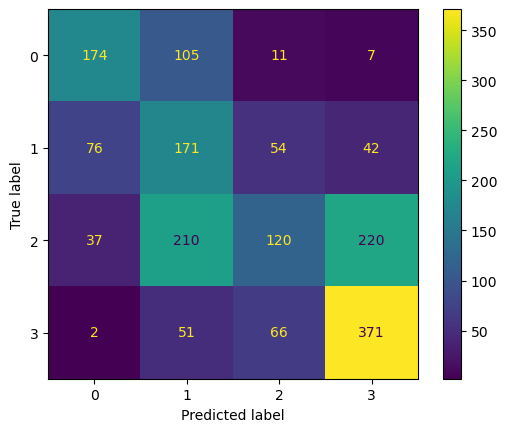

In [20]:
#surv6m
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc_test,values_format = '')
plt.show()

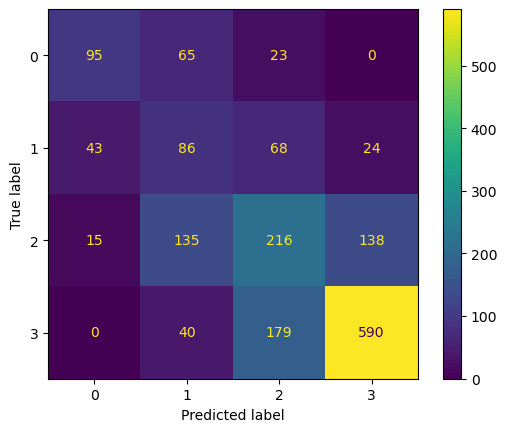

In [35]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc_test,values_format = '')
plt.show()

In [379]:
# RocCurveDisplay.from_estimator(svc_pipe_2m, X_test, y_test, plot_chance_level=True, marker = 'o')
# plt.title("Receiver Operating Characteristic (ROC) curves")
# plt.grid(linestyle="--")
# plt.show()

## Linaer SVC

In [21]:
from sklearn.svm import LinearSVC

lsvc_pipe_2m = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("SMOTE", SMOTE(random_state = 42)),
    # ("RandomOverSampler", RandomOverSampler(random_state = 42)),
    ('Linearsvm', LinearSVC(C  =1.0, class_weight= "balanced"))
])


# Fit the pipeline on the training data for 2-month survival
lsvc_pipe_2m.fit(X_train, y_train)



strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_lsvc = cross_val_predict(lsvc_pipe_2m, X, y, cv=strat_kfold, n_jobs=-1)



C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [22]:
y_pred_lsvc_test = lsvc_pipe_2m.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_lsvc_test))
print('F1-score %s' % f1_score(y_test, y_pred_lsvc_test, average=None))
print(classification_report(y_test, y_pred_lsvc_test))

Accuracy 0.5544554455445545
F1-score [0.63386397 0.36552749 0.41069519 0.73656388]
              precision    recall  f1-score   support

           0       0.56      0.74      0.63       297
           1       0.37      0.36      0.37       343
           2       0.55      0.33      0.41       587
           3       0.65      0.85      0.74       490

    accuracy                           0.55      1717
   macro avg       0.53      0.57      0.54      1717
weighted avg       0.54      0.55      0.53      1717



In [38]:
lsvc_pipe_2m

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['urine', 'totcst', 'hrt',
                                                   'adlp', 'adls', 'totmcst',
                                                   'sod', 'avtisst', 'glucose',
                                                   'wblc', 'crea', 'diabetes',
                                                   'temp', 'adlsc', 'alb',
                                                   'scoma', 'bun', 'dementia',
                                                   'ph', 'age', 'pafi', 'bili',
                                                   'hday', 'hospdead', 'slos',
                                                   'num.co', 'me...
                                                                   RobustScaler())]),
                                                  ['income', 'sfdm2']),
                                                 ('onehot_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['sex', 'dzgroup', 'dzclass', 'race', 'ca'], dtype='object'))])),
                ('SMOTE', SMOTE(random_state=42)),
                ('Linearsvm', LinearSVC(class_weight='balanced'))])

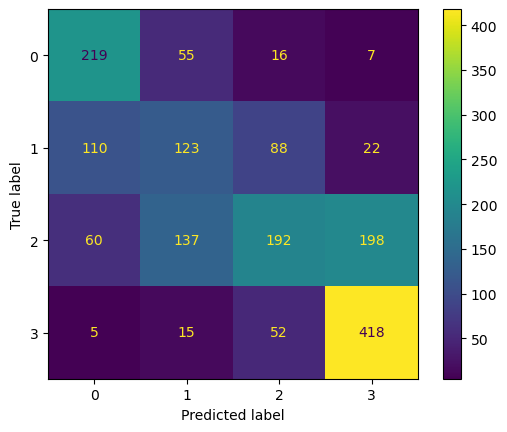

ValueError: Expected 'estimator' to be a binary classifier. Got 4 classes instead.

In [23]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lsvc_test,values_format = '')
plt.show()
RocCurveDisplay.from_estimator(lsvc_pipe_2m, X_test, y_test, plot_chance_level=True, marker = 'o')
plt.title("Receiver Operating Characteristic (ROC) curves")
plt.grid(linestyle="--")
plt.show()

## for neural network

### without pipeline
#### this code works

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler

# Step 1: Imputation
most_freq_imputer = SimpleImputer(strategy='most_frequent')
X_train_imputed_cat = most_freq_imputer.fit_transform(X_train[categorical_df.columns]) 
# X_train_imputed_cat = pd.DataFrame(X_train_imputed_cat)

# Step 2: Ordinal Encoding
ordinal_encoder = OrdinalEncoder(categories=[
    ['under $11k', '$11-$25k', '$25-$50k', '>$50k'], 
    ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']
])

# X_encoded_ord = ordinal_encoder.fit_transform(X_train_imputed_cat[[3,6]])
X_encoded_ord = ordinal_encoder.fit_transform(X_train_imputed_cat[:,[3,6]])
X_encoded_ord = pd.DataFrame(X_encoded_ord)
# Step 3: onehotencoding
# onehot_encoder = OneHotEncoder()
# X_encoded_onehot = onehot_encoder.fit_transform(X_train_imputed_cat[categorical_df.drop(["income", "sfdm2"], axis = 1).columns])


onehot_encoder = OneHotEncoder(sparse_output=False)
categorical_columns_to_encode = np.delete(X_train_imputed_cat, [3,6], axis=1)
# categorical_columns_to_encode = categorical_df.drop(["income", "sfdm2"], axis=1).columns
X_encoded_onehot = onehot_encoder.fit_transform(np.delete(X_train_imputed_cat, [3,6], axis=1))


# arr_without_column = np.delete(X_train_imputed_cat, [3,6], axis=1)


# Step 4: Imputation of numerical variables
mean_imputer = SimpleImputer(strategy='mean')
X_train_imputed_num = mean_imputer.fit_transform(X_train[numerical_df.columns]) 

# Step 5: concatanating all the columns\
# X_train_imputed_encoded = pd.concat([X_train_imputed_num + X_encoded_ord + X_encoded_onehot])
X_train_imputed_encoded = np.concatenate((X_train_imputed_num, X_encoded_ord, X_encoded_onehot), axis = 1)
# Step 5: Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_train_imputed_encoded)

In [ ]:
col_cats_name

In [ ]:
col_cats_name.pop('income')

In [ ]:
categorical_vars, 

In [ ]:
columns_most_frequent = ['edu', 'sfdm2']
columns_mean = ['age', 'income']

# Create transformers for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, columns_mean),
        ('cat', categorical_transformer, columns_most_frequent)
    ])

# Create a full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
a

In [ ]:
df["income"]

In [ ]:
encoder = OrdinalEncoder()
df[['sex']] = encoder.fit_transform(df[['sex']]).astype('int')

In [ ]:
col_cats_name.pop(0)

In [ ]:
df.head()

In [ ]:
df = pd.get_dummies(df, columns=col_cats_name)

In [ ]:
dfs.columns

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
plt.figure(figsize=(48, 48))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=.5, annot_kws={"size": 10})
plt.title('Correlation Matrix between All Variables')
plt.show()

In [64]:
dfs = df.copy()

In [ ]:
dfs_y = dfs.death
dfs_x = dfs.drop(["death"], axis = 1)

In [ ]:
dfs_x.info()

In [ ]:
cols_to_scale = ['age', 'edu', 'num.co', 'scoma', 'charges', 'avtisst','hday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adlsc']

In [ ]:
sc = StandardScaler()
dfs_x[cols_to_scale] =  sc.fit_transform(dfs_x[cols_to_scale].values)

In [ ]:
dfs_x.head()

In [ ]:
pca = PCA()
pca.fit_transform(dfs_x)
print(np.sum(pca.explained_variance_ratio_))
per_var = np.round(pca.explained_variance_ratio_,decimals=1)
labels = ['' + str(x) for x in range(1, len(per_var)+1)]
plt.subplots(nrows=1, ncols=1, figsize=(12, 12))
plt.bar(x=range(1,len(pca.explained_variance_ratio_)+1), height=pca.explained_variance_ratio_, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

In [ ]:
X = dfs.drop(columns = ["surv2m"])

In [ ]:
y = dfs["surv2m"]

## Voting Classifier

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline  # Using imbalanced-learn's pipeline if needed

# Define the preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']])),
    ('scaler', RobustScaler())
])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ordinal_cat', ordinal_transformer, ordinal_cols),
        ('onehot_cat', onehot_transformer, onehot_cols)
    ])

# Define base models for the ensemble
log_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
knn_clf = KNeighborsClassifier()
rf_clf = RandomForestClassifier(class_weight='balanced')
svc_clf = SVC(probability=True, class_weight='balanced')  # Ensure probability=True for soft voting
gb_clf = GradientBoostingClassifier()
et_clf = ExtraTreesClassifier(class_weight='balanced')

# Create a Voting Classifier with more classifiers
voting_clf = VotingClassifier(estimators=[
    ('lr', log_clf),
    ('knn', knn_clf),
    ('rf', rf_clf),
    ('svc', svc_clf),  # Ensure SVC is properly initialized with probability=True
    ('gb', gb_clf),
    ('et', et_clf)
], voting='soft')  # Using soft voting for probabilistic predictions

# Create the pipeline with the ensemble classifier
ensemble_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("SMOTE", SMOTE(random_state = 42)),
    ('pca', PCA(n_components=0.95)),
    ('voting', voting_clf)  # Use the voting classifier here
])



In [61]:
ensemble_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['diabetes', 'd.time', 'wblc',
                                                   'crea', 'hospdead',
                                                   'avtisst', 'scoma',
                                                   'totmcst', 'alb', 'meanbp',
                                                   'hrt', 'hday', 'adls',
                                                   'bili', 'ph', 'totcst',
                                                   'resp', 'sod', 'bun',
                                                   'dementia', 'adlp', 'age',
                                                   'edu', 'temp', 'glucose',
                                                   'adlsc', 'de...
                ('voting',
                 VotingClassifier(estimators=[('lr',
                                               LogisticRegression(class_weight='balanced',
                                                                  max_iter=1000)),
                                              ('knn', KNeighborsClassifier()),
                                              ('rf',
                                               RandomForestClassifier(class_weight='balanced')),
                                              ('svc',
                                               SVC(class_weight='balanced',
                                                   probability=True)),
                                              ('gb',
                                               GradientBoostingClassifier()),
                                              ('et',
                                               ExtraTreesClassifier(class_weight='balanced'))],
                                  voting='soft'))])

In [63]:
!pip install graphviz

In [69]:
from sklearn import set_config
set_config(display='diagram')  # enables pipeline diagram visualization in notebooks

ensemble_pipeline  # just output the pipeline in a Jupyter cell

from sklearn.utils import estimator_html_repr

with open("ensemble_pipeline.html", "w", encoding="utf-8") as f:
    f.write(estimator_html_repr(ensemble_pipeline))



In [70]:
# Now you can train and evaluate your pipeline as usual
# Assuming X_train, y_train, X_test, y_test are defined
ensemble_pipeline.fit(X_train, y_train)
y_pred = ensemble_pipeline.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score
print('Ensemble Model Accuracy:', accuracy_score(y_test, y_pred))


C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Ensemble Model Accuracy: 0.5393127548048923


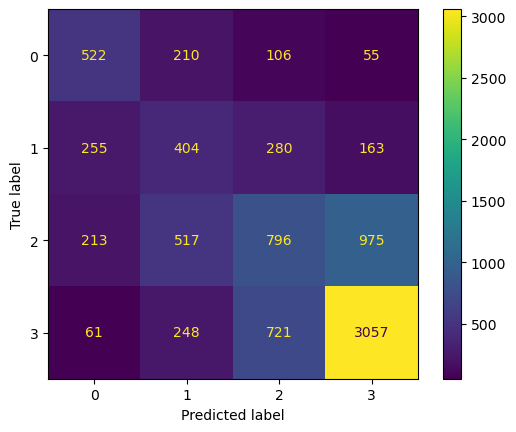

In [73]:
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_ensemble = cross_val_predict(ensemble_pipeline, X, y, cv=strat_kfold, n_jobs=-1)
ConfusionMatrixDisplay.from_predictions(y, y_pred_ensemble,values_format = '')
plt.show()

In [74]:
y_pred_ensemble = ensemble_pipeline.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_ensemble))
print('F1-score %s' % f1_score(y_test, y_pred_ensemble, average=None))
print(classification_report(y_test, y_pred_ensemble))

Accuracy 0.5393127548048923
F1-score [0.51243781 0.28056112 0.37372593 0.71272727]
              precision    recall  f1-score   support

           0       0.47      0.56      0.51       183
           1       0.25      0.32      0.28       221
           2       0.44      0.33      0.37       504
           3       0.70      0.73      0.71       809

    accuracy                           0.54      1717
   macro avg       0.46      0.48      0.47      1717
weighted avg       0.54      0.54      0.54      1717



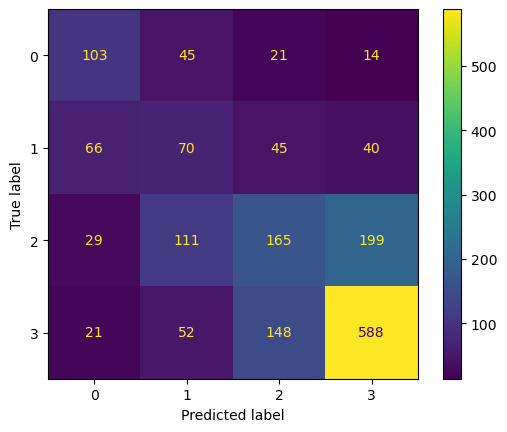

In [76]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ensemble,values_format = '')
plt.show()

# Second Take

### 1st Neural Net

In [25]:
df_afterdropping['surv2m']=pd.cut(df.surv2m,bins = 4, labels = [0,1,2,3])
X = df_afterdropping.drop(["surv2m"], axis = 1)
y = df_afterdropping["surv2m"]
mode_value = y.mode()[0]
y = y.fillna(mode_value)

AttributeError: 'DataFrame' object has no attribute 'surv2m'

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((6866, 39), (6866,), (1717, 39), (1717,))

In [45]:
# from imblearn.over_sampling import SMOTE
# sampler = SMOTE()
# X_train, y_train = sampler.fit_resample(X_train, y_train)
# print(pd.Series(X_train).value_counts())

In [46]:
# Define the preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    # ('robust_scaler', RobustScaler())
    ("standard_scaler", StandardScaler())
    
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']])),
    # ('scaler', RobustScaler())
    ("standard_scaler", StandardScaler())
])
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # ('dummify', FunctionTransformer(dummify)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output = False)),
    # ('scaler', RobustScaler())
    ("standard_scaler", StandardScaler())
])



preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ordinal_cat', ordinal_transformer, ordinal_cols),
        ("onehot_cat", onehot_transformer, onehot_cols)
    ])


svc_pipe_2m = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    # ("SMOTE", SMOTE(random_state = 42))
])






In [47]:
X_train

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,hday,diabetes,dementia,ca,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
2930,91.71796,0,female,0,19,668,ARF/MOSF w/Sepsis,ARF/MOSF,4,6.0,under $11k,0.0,52128.0,38784.8750,30594.68750,26.333328,white,2,1,0,no,43.0,15.500000,113.0,16.0,37.79688,154.00000,1.899902,0.099991,0.899902,146.0,7.299805,186.0,14.0,1338.0,NaN,2.0,adl>=4 (>=5 if sur),2.000000
65,64.64294,1,male,0,17,254,ARF/MOSF w/Sepsis,ARF/MOSF,3,12.0,NaN,9.0,180786.0,95272.6875,NaN,25.333328,white,17,1,0,no,68.0,13.298828,92.0,38.0,38.79688,113.67188,3.399902,1.099854,2.299805,133.0,7.479492,NaN,NaN,NaN,NaN,0.0,no(M2 and SIP pres),0.000000
7075,65.69196,1,male,0,25,253,ARF/MOSF w/Sepsis,ARF/MOSF,2,18.0,NaN,0.0,54606.0,36313.7812,40016.81250,24.250000,white,4,0,0,yes,53.0,13.500000,114.0,12.0,35.39844,226.65625,1.799805,4.099609,2.500000,134.0,7.419922,194.0,30.0,362.0,NaN,0.0,no(M2 and SIP pres),0.000000
7040,67.25299,1,male,0,11,24,Lung Cancer,Cancer,2,NaN,NaN,0.0,12915.0,8760.2344,12108.28910,18.000000,white,1,0,0,metastatic,129.0,10.199219,146.0,38.0,36.79688,436.00000,NaN,NaN,1.299805,141.0,7.419922,119.0,27.0,820.0,NaN,NaN,<2 mo. follow-up,4.027344
6759,37.34998,0,male,0,68,1073,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,205034.0,133860.3750,153891.25000,49.750000,white,2,1,0,no,62.0,14.199219,120.0,34.0,38.29688,240.00000,NaN,NaN,2.299805,144.0,7.419922,308.0,83.0,4245.0,NaN,NaN,NaN,3.105957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6047,59.13498,1,female,0,5,1401,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,3112.0,2397.3359,700.76953,10.000000,white,1,0,0,no,62.0,6.799805,120.0,23.0,36.59375,NaN,2.599609,2.099609,1.299805,135.0,NaN,NaN,NaN,NaN,0.0,2.0,no(M2 and SIP pres),2.000000
5490,51.02298,0,male,0,6,501,ARF/MOSF w/Sepsis,ARF/MOSF,1,18.0,under $11k,0.0,22219.0,NaN,NaN,25.000000,black,4,1,0,no,97.0,11.599609,60.0,20.0,36.69531,101.65625,4.099609,0.699951,6.699219,134.0,7.329102,92.0,46.0,3205.0,0.0,NaN,no(M2 and SIP pres),0.494751
5698,66.80896,1,male,1,11,11,Lung Cancer,Cancer,2,12.0,under $11k,9.0,9857.0,NaN,NaN,11.500000,white,1,1,0,metastatic,72.0,6.799805,75.0,32.0,35.29688,287.75000,2.699707,0.399963,1.299805,126.0,7.419922,96.0,49.0,2555.0,NaN,0.0,<2 mo. follow-up,0.000000
901,35.52597,1,female,1,9,9,ARF/MOSF w/Sepsis,ARF/MOSF,3,14.0,under $11k,41.0,190585.0,50592.1562,53178.53120,52.000000,white,12,0,0,yes,135.0,5.000000,120.0,20.0,36.50000,153.31250,NaN,NaN,0.799927,149.0,7.449219,399.0,26.0,1770.0,NaN,0.0,<2 mo. follow-up,0.000000


In [48]:
# Fit the pipeline on the training data for 2-month survival
svc_pipe_2m.fit(X_train)
X_train = svc_pipe_2m.transform(X_train)
X_test = svc_pipe_2m.transform(X_test)

# from imblearn.over_sampling import SMOTE
sampler = SMOTE()
X_train, y_train = sampler.fit_resample(X_train, y_train)
# print(pd.Series(X_train).value_counts())

In [49]:
X_train.shape, X_test.shape, y_train.shape,y_test.shape

((13112, 56), (1717, 56), (13112,), (1717,))

In [50]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

In [51]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

In [52]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((13112, 56), (13112,), (1717, 56), (1717,))

In [53]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13112, 56), (1717, 56), (13112, 4), (1717, 4))

In [54]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2, l1
from keras.wrappers.scikit_learn import KerasClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.datasets import mnist
from keras.wrappers.scikit_learn import KerasClassifier
from keras.datasets import mnist
from keras.models import Sequential
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Activation, Dense, BatchNormalization, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping


def mlp_model():
    model = Sequential()

    model.add(Dense(X_train.shape[1], input_shape = (X_train.shape[1], ), kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    # model.add(Dense(14, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    # model.add(BatchNormalization())
    # model.add(Activation('relu'))
    # model.add(Dropout(0.2))
    model.add(Dense(y_train.shape[1], kernel_initializer='he_normal'))
    model.add(Activation('softmax'))

    rms_prop=optimizers.RMSprop(1e-2)
    sgd = optimizers.SGD(learning_rate = 0.01)
    adam = optimizers.Adam(learning_rate = 0.001)
    
    model.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])

    return model

In [55]:
model = mlp_model()

In [57]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 56)                3192      
                                                                 
 batch_normalization (BatchN  (None, 56)               224       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 56)                0         
                                                                 
 dropout (Dropout)           (None, 56)                0         
                                                                 
 dense_1 (Dense)             (None, 28)                1596      
                                                                 
 batch_normalization_1 (Batc  (None, 28)               112       
 hNormalization)                                        

In [9]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split = 0.2, epochs = 50, batch_size = 128, verbose = 1, callbacks = [early_stopping])

Epoch 1/50
82/82 [==============================] - 3s 12ms/step - loss: 4.4542 - accuracy: 0.3208 - val_loss: 4.0804 - val_accuracy: 0.0648
Epoch 2/50
82/82 [==============================] - 0s 6ms/step - loss: 3.4855 - accuracy: 0.4468 - val_loss: 3.4498 - val_accuracy: 0.0194
Epoch 3/50
82/82 [==============================] - 0s 5ms/step - loss: 2.8356 - accuracy: 0.4896 - val_loss: 2.9426 - val_accuracy: 0.0065
Epoch 4/50
82/82 [==============================] - 0s 5ms/step - loss: 2.3489 - accuracy: 0.5230 - val_loss: 2.5657 - val_accuracy: 0.0400
Epoch 5/50
82/82 [==============================] - 0s 5ms/step - loss: 1.9687 - accuracy: 0.5553 - val_loss: 2.2681 - val_accuracy: 0.0740
Epoch 6/50
82/82 [==============================] - 0s 5ms/step - loss: 1.6854 - accuracy: 0.5756 - val_loss: 2.0346 - val_accuracy: 0.1346
Epoch 7/50
82/82 [==============================] - 0s 5ms/step - loss: 1.4880 - accuracy: 0.5905 - val_loss: 1.8075 - val_accuracy: 0.2390
Epoch 8/50
82/82 [=

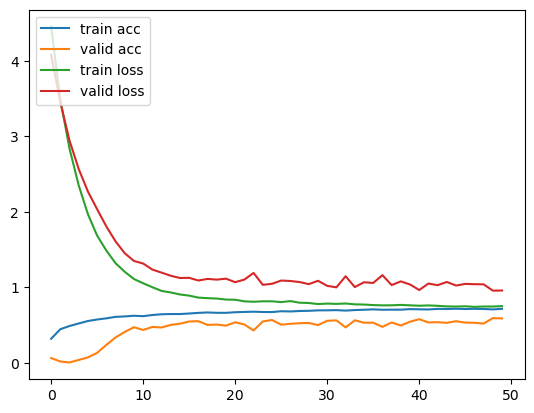

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train acc', 'valid acc', 'train loss', 'valid loss'], loc = 'upper left')
plt.show()

In [13]:
results = model.evaluate(X_test, y_test)

54/54 [==============================] - 0s 3ms/step - loss: 0.8335 - accuracy: 0.6634


### 2nd Neural Net

In [189]:

# Define the MLP model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Use softmax for classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)

Epoch 1/50
172/172 [==============================] - 2s 4ms/step - loss: 1.1934 - accuracy: 0.4676 - val_loss: 0.9893 - val_accuracy: 0.5735
Epoch 2/50
172/172 [==============================] - 0s 2ms/step - loss: 0.9778 - accuracy: 0.5641 - val_loss: 0.8970 - val_accuracy: 0.6033
Epoch 3/50
172/172 [==============================] - 0s 2ms/step - loss: 0.9065 - accuracy: 0.6018 - val_loss: 0.8526 - val_accuracy: 0.6332
Epoch 4/50
172/172 [==============================] - 0s 2ms/step - loss: 0.8500 - accuracy: 0.6255 - val_loss: 0.8216 - val_accuracy: 0.6361
Epoch 5/50
172/172 [==============================] - 0s 2ms/step - loss: 0.8134 - accuracy: 0.6404 - val_loss: 0.7998 - val_accuracy: 0.6441
Epoch 6/50
172/172 [==============================] - 0s 2ms/step - loss: 0.7953 - accuracy: 0.6535 - val_loss: 0.7986 - val_accuracy: 0.6608
Epoch 7/50
172/172 [==============================] - 0s 2ms/step - loss: 0.7735 - accuracy: 0.6599 - val_loss: 0.7894 - val_accuracy: 0.6623
Epoch 

In [190]:
loss, accuracy = model.evaluate(X_test, y_test)
print('Test accuracy:', accuracy)

54/54 [==============================] - 0s 1ms/step - loss: 0.7479 - accuracy: 0.6826
Test accuracy: 0.6825858950614929


In [191]:
print("Test Accuracy", results[1])

Test Accuracy 0.6802562475204468


[0.31560805439949036, 0.8823529481887817]

### Trying Ensemble Method

In [24]:
# df_afterdropping['surv2m']=pd.cut(df.surv2m,bins = 4, labels = [0,1,2,3])
# X = df_afterdropping.drop(["surv2m"], axis = 1)
# y = df_afterdropping["surv2m"]
# mode_value = y.mode()[0]
# y = y.fillna(mode_value)



X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

# converting y data into categorical (one-hot encoding)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


y_train = np.argmax(y_train, axis = 1)
y_test = np.argmax(y_test, axis = 1)

NameError: name 'X_preprocessed' is not defined

In [59]:
y_train[0]

array([0., 0., 1., 0.], dtype=float32)

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2, l1
from keras.wrappers.scikit_learn import KerasClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.datasets import mnist
from keras.wrappers.scikit_learn import KerasClassifier
from keras.datasets import mnist
from keras.models import Sequential
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Activation, Dense, BatchNormalization, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping


def mlp_model_ens():
    model = Sequential()

    model.add(Dense(56, input_shape = (56, )))
    model.add(Activation('sigmoid'))
    model.add(Dense(28))
    model.add(Activation('sigmoid'))
    model.add(Dense(28))
    model.add(Activation('sigmoid'))
    model.add(Dense(14))
    model.add(Activation('sigmoid'))
    model.add(Dense(4))
    model.add(Activation('softmax'))

    sgd = optimizers.SGD(learning_rate = 0.001)
    model.compile(optimizer = sgd, loss = 'categorical_crossentropy', metrics = ['accuracy'])

    return model

C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\fardi\anaconda3\envs\ml2\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it w

In [297]:
model1 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30)
model2 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30)
model3 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30)
# model4 = KerasClassifier(build_fn = mlp_model, epochs = 30)
# model5 = KerasClassifier(build_fn = mlp_model, epochs = 30)

model1._estimator_type = "classifier"
model2._estimator_type = "classifier"
model3._estimator_type = "classifier"
# model4._estimator_type = "classifier"
# model5._estimator_type = "classifier"



ensemble_clf = VotingClassifier(estimators = [('model1', model1), ('model2', model2), ('model3', model3),]
                                , voting = 'soft')

C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\411593138.py:1: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model1 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30)
C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\411593138.py:2: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model2 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30)
C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\411593138.py:3: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model3 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30)


In [298]:
ensemble_clf.fit(X_train, y_train)

Epoch 1/30
215/215 [==============================] - 1s 3ms/step - loss: 1.9124 - accuracy: 0.1283
Epoch 2/30
215/215 [==============================] - 1s 3ms/step - loss: 1.6393 - accuracy: 0.1283
Epoch 3/30
215/215 [==============================] - 1s 3ms/step - loss: 1.4655 - accuracy: 0.1317
Epoch 4/30
215/215 [==============================] - 1s 3ms/step - loss: 1.3593 - accuracy: 0.3227
Epoch 5/30
215/215 [==============================] - 1s 3ms/step - loss: 1.2967 - accuracy: 0.4774
Epoch 6/30
215/215 [==============================] - 1s 3ms/step - loss: 1.2607 - accuracy: 0.4774
Epoch 7/30
215/215 [==============================] - 1s 3ms/step - loss: 1.2401 - accuracy: 0.4774
Epoch 8/30
215/215 [==============================] - 1s 3ms/step - loss: 1.2283 - accuracy: 0.4774
Epoch 9/30
215/215 [==============================] - 1s 3ms/step - loss: 1.2215 - accuracy: 0.4774
Epoch 10/30
215/215 [==============================] - 1s 3ms/step - loss: 1.2174 - accuracy: 0.4774

VotingClassifier(estimators=[('model1',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CC75C63B0>),
                             ('model2',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CC75C74F0>),
                             ('model3',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CDB6558D0>)],
                 voting='soft')

### 2nd Ensemble 

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2, l1
from keras.wrappers.scikit_learn import KerasClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.datasets import mnist
from keras.wrappers.scikit_learn import KerasClassifier
from keras.datasets import mnist
from keras.models import Sequential
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Activation, Dense, BatchNormalization, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping


def mlp_model_ens():
    model = Sequential()

    model.add(Dense(X_train.shape[1], input_shape = (X_train.shape[1], ), kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    # model.add(Dense(14, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    # model.add(BatchNormalization())
    # model.add(Activation('relu'))
    # model.add(Dropout(0.2))
    model.add(Dense(4, kernel_initializer='he_normal'))
    model.add(Activation('softmax'))

    rms_prop=optimizers.RMSprop(1e-2)
    sgd = optimizers.SGD(learning_rate = 0.01)
    adam = optimizers.Adam(learning_rate = 0.001)
    
    model.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])

    return model

In [23]:
model= mlp_model_ens()

NameError: name 'X_train' is not defined

In [20]:
from tensorflow.keras.utils import plot_model
dot_img_file = 'model_1.png'
plot_model(mlp_model_ens, to_file=dot_img_file, show_shapes=True)

AttributeError: 'function' object has no attribute 'built'

In [313]:
# create 5 models to ensemble
model1 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)
model2 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)
model3 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)
model4 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)
model5 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)

model1._estimator_type = "classifier"
model2._estimator_type = "classifier"
model3._estimator_type = "classifier"
model4._estimator_type = "classifier"
model5._estimator_type = "classifier"

C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\4218327409.py:2: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model1 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)
C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\4218327409.py:3: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model2 = KerasClassifier(build_fn = mlp_model_ens, epochs = 30, validation_split = 0.2, batch_size = 128)
C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\4218327409.py:4: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  mo

In [314]:
ensemble_clf = VotingClassifier(estimators = [('model1', model1), ('model2', model2), ('model3', model3), ('model4', model4), ('model5', model5)]
                                , voting = 'soft')

In [315]:
ensemble_clf.fit(X_train, y_train)

Epoch 1/30
43/43 [==============================] - 3s 16ms/step - loss: 4.8198 - accuracy: 0.2859 - val_loss: 4.3873 - val_accuracy: 0.3137
Epoch 2/30
43/43 [==============================] - 0s 7ms/step - loss: 4.1181 - accuracy: 0.4155 - val_loss: 3.7462 - val_accuracy: 0.5102
Epoch 3/30
43/43 [==============================] - 0s 7ms/step - loss: 3.6573 - accuracy: 0.4641 - val_loss: 3.3265 - val_accuracy: 0.5284
Epoch 4/30
43/43 [==============================] - 0s 7ms/step - loss: 3.2706 - accuracy: 0.4965 - val_loss: 2.9930 - val_accuracy: 0.5517
Epoch 5/30
43/43 [==============================] - 0s 7ms/step - loss: 2.9486 - accuracy: 0.5078 - val_loss: 2.7056 - val_accuracy: 0.5655
Epoch 6/30
43/43 [==============================] - 0s 7ms/step - loss: 2.6809 - accuracy: 0.5178 - val_loss: 2.4634 - val_accuracy: 0.5750
Epoch 7/30
43/43 [==============================] - 0s 7ms/step - loss: 2.4256 - accuracy: 0.5395 - val_loss: 2.2531 - val_accuracy: 0.5786
Epoch 8/30
43/43 [=

VotingClassifier(estimators=[('model1',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CDD6D20B0>),
                             ('model2',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CDD6D35B0>),
                             ('model3',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CC4737B50>),
                             ('model4',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CDD6D17B0>),
                             ('model5',
                              <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000014CDD6D1A50>)],
                 voting='soft')

In [316]:
y_pred = ensemble_clf.predict(X_test)

54/54 [==============================] - 0s 1ms/step


In [317]:
print('Acc: ', accuracy_score(y_pred, y_test))

Acc:  0.6790914385556203


# Classification with Surv6m

## Ensemble classification task

In [318]:
columns_to_check = ["scoma", "charges", "avtisst", "race", 
                    "meanbp", "wblc", "hrt", "resp", "temp", "crea", "sod"]

# Drop rows where any of the specified columns have missing values
df_afterdropping = df.dropna(subset=columns_to_check)

In [319]:
# train test split
df_afterdropping['surv6m']=pd.cut(df.surv2m,bins = 4, labels = [0,1,2,3])
X = df_afterdropping.drop(["surv6m"], axis = 1)
y = df_afterdropping["surv6m"]
mode_value = y.mode()[0]
y = y.fillna(mode_value)
# y.iloc[5393] = mode_value
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 42)

C:\Users\fardi\AppData\Local\Temp\ipykernel_22500\1674230931.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afterdropping['surv6m']=pd.cut(df.surv2m,bins = 4, labels = [0,1,2,3])


In [320]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline  # Using imbalanced-learn's pipeline if needed

# Define the preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']])),
    ('scaler', RobustScaler())
])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ordinal_cat', ordinal_transformer, ordinal_cols),
        ('onehot_cat', onehot_transformer, onehot_cols)
    ])

# Define base models for the ensemble
log_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
knn_clf = KNeighborsClassifier()
rf_clf = RandomForestClassifier(class_weight='balanced')
svc_clf = SVC(probability=True, class_weight='balanced')  # Ensure probability=True for soft voting
gb_clf = GradientBoostingClassifier()
et_clf = ExtraTreesClassifier(class_weight='balanced')

# Create a Voting Classifier with more classifiers
voting_clf = VotingClassifier(estimators=[
    ('lr', log_clf),
    ('knn', knn_clf),
    ('rf', rf_clf),
    ('svc', svc_clf),  # Ensure SVC is properly initialized with probability=True
    ('gb', gb_clf),
    ('et', et_clf)
], voting='soft')  # Using soft voting for probabilistic predictions

# Create the pipeline with the ensemble classifier
ensemble_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('voting', voting_clf)  # Use the voting classifier here
])

# Now you can train and evaluate your pipeline as usual
# Assuming X_train, y_train, X_test, y_test are defined
ensemble_pipeline.fit(X_train, y_train)
y_pred = ensemble_pipeline.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score
print('Ensemble Model Accuracy:', accuracy_score(y_test, y_pred))


Ensemble Model Accuracy: 0.5783343040186372


Accuracy 0.5783343040186372
F1-score [0.56626506 0.19607843 0.39236479 0.73826228]
              precision    recall  f1-score   support

           0       0.63      0.51      0.57       183
           1       0.35      0.14      0.20       221
           2       0.42      0.37      0.39       504
           3       0.66      0.85      0.74       809

    accuracy                           0.58      1717
   macro avg       0.52      0.47      0.47      1717
weighted avg       0.55      0.58      0.55      1717



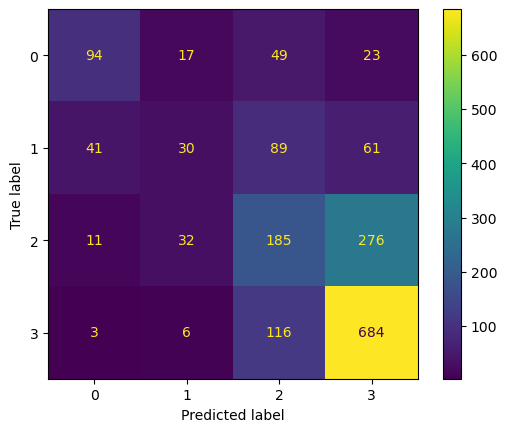

In [323]:
y_pred_6m_test = ensemble_pipeline.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_6m_test))
print('F1-score %s' % f1_score(y_test, y_pred_6m_test, average=None))
print(classification_report(y_test, y_pred_6m_test))
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_6m_test,values_format = '')
plt.show()

## Neural net- surv6m

In [12]:
df_afterdropping['surv6m']=pd.cut(df.surv2m,bins = [0,.25,0.5,0.75,1], labels = [0,1,2,3])
X = df_afterdropping.drop(["surv6m"], axis = 1)
y = df_afterdropping["surv6m"]
mode_value = y.mode()[0]
y = y.fillna(mode_value)

C:\Users\fardi\AppData\Local\Temp\ipykernel_29748\3842106486.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afterdropping['surv6m']=pd.cut(df.surv2m,bins = [0,.25,0.5,0.75,1], labels = [0,1,2,3])


In [14]:
type(X_preprocessed)

NameError: name 'X_preprocessed' is not defined

In [373]:
X_preprocessed.shape, y.shape

((8583, 56), (8583,))

In [358]:
np.isnan

0

((16348, 56), (16348,))

In [24]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder


# Define the preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['Coma or Intub', 'SIP>=30', 'adl>=4 (>=5 if sur)', 'no(M2 and SIP pres)', '<2 mo. follow-up']])),
    ('scaler', RobustScaler())
])
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # ('dummify', FunctionTransformer(dummify)),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
    ('scaler', RobustScaler())
])



preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ordinal_cat', ordinal_transformer, ordinal_cols),
        ("onehot_cat", onehot_transformer, onehot_cols)
    ])


svc_pipe_2m = Pipeline(steps=[
    ('preprocessor', preprocessor),
])



# Fit the pipeline on the training data for 2-month survival
X_preprocessed = svc_pipe_2m.fit_transform(X)



In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

In [28]:
# y_train = to_categorical(y_train)
# y_test = to_categorical(y_test)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6866, 56), (1717, 56), (6866,), (1717,))

In [ ]:
from imblearn.over_sampling import SMOTE
sampler = SMOTE()
X1_SMOTE, Y1_SMOTE = sampler.fit_resample(X_train, y_train)
print(pd.Series(Y1_SMOTE).value_counts())

In [32]:
np.save('X1_SMOTE.npy', X1_SMOTE)
np.save('Y1_SMOTE.npy', Y1_SMOTE)


In [33]:
X1_SMOTE = np.load('X1_SMOTE.npy')
Y1_SMOTE = np.load('Y1_SMOTE.npy')

In [34]:
X1_SMOTE.shape, Y1_SMOTE.shape

((16348, 56), (16348,))

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2, l1
from keras.wrappers.scikit_learn import KerasClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.datasets import mnist
from keras.wrappers.scikit_learn import KerasClassifier
from keras.datasets import mnist
from keras.models import Sequential
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Activation, Dense, BatchNormalization, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping


def mlp_model():
    model = Sequential()

    model.add(Dense(X_train.shape[1], input_shape = (X_train.shape[1], ), kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(28, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    # model.add(Dense(14, kernel_initializer='he_normal', kernel_regularizer=l2(0.01)))
    # model.add(BatchNormalization())
    # model.add(Activation('relu'))
    # model.add(Dropout(0.2))
    model.add(Dense(y_train.shape[1], kernel_initializer='he_normal'))
    model.add(Activation('softmax'))

    rms_prop=optimizers.RMSprop(1e-2)
    sgd = optimizers.SGD(learning_rate = 0.01)
    adam = optimizers.Adam(learning_rate = 0.001)
    
    model.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])

    return model

In [15]:
model = mlp_model()

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split = 0.2, epochs = 50, batch_size = 128, verbose = 1, callbacks = [early_stopping])

Epoch 1/50
82/82 [==============================] - 3s 9ms/step - loss: 4.5221 - accuracy: 0.3275 - val_loss: 4.1244 - val_accuracy: 0.0149
Epoch 2/50
82/82 [==============================] - 0s 5ms/step - loss: 3.5732 - accuracy: 0.4459 - val_loss: 3.4931 - val_accuracy: 0.0015
Epoch 3/50
82/82 [==============================] - 0s 5ms/step - loss: 2.8902 - accuracy: 0.5038 - val_loss: 2.9838 - val_accuracy: 0.0019
Epoch 4/50
82/82 [==============================] - 0s 5ms/step - loss: 2.3812 - accuracy: 0.5450 - val_loss: 2.5589 - val_accuracy: 0.0274
Epoch 5/50
82/82 [==============================] - 0s 5ms/step - loss: 2.0038 - accuracy: 0.5629 - val_loss: 2.2283 - val_accuracy: 0.0682
Epoch 6/50
82/82 [==============================] - 0s 5ms/step - loss: 1.7107 - accuracy: 0.5886 - val_loss: 1.9354 - val_accuracy: 0.1647
Epoch 7/50
82/82 [==============================] - 0s 5ms/step - loss: 1.4927 - accuracy: 0.6007 - val_loss: 1.7055 - val_accuracy: 0.3054
Epoch 8/50
82/82 [==

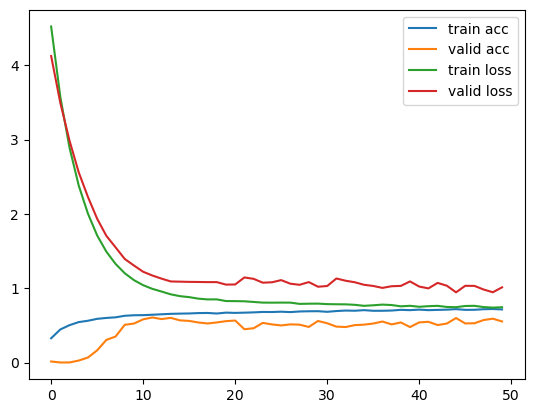

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train acc', 'valid acc', 'train loss', 'valid loss'], loc = 'upper right')
plt.show()

In [18]:
results = model.evaluate(X_test, y_test)

54/54 [==============================] - 0s 1ms/step - loss: 0.8466 - accuracy: 0.6587
